E-commerce Recommendation System

Step 1 - Importing important libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time, os, re, pickle
from datetime import datetime
from collections import defaultdict
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#FAFAFA',
                     'axes.spines.top':False,'axes.spines.right':False})
PALETTE = ['#4C6EF5','#F76707','#2F9E44','#E03131','#7048E8',
           '#0C8599','#D6336C','#F59F00','#364FC7','#5C940D']

# ════════════════════════════════════════════════
#  SET YOUR FILE PATHS HERE
# ════════════════════════════════════════════════
USERS_CSV    = 'data/users.csv'
PRODUCTS_CSV = 'data/products.csv'
REVIEWS_CSV  = 'data/reviews.csv'
CARTS_CSV    = 'data/carts.csv'
ORDERS_CSV   = 'data/orders.csv'

# Model hyperparameters
CONFIG = {
    'test_size':    0.20,
    'random_seed':  42,
    'knn_k':        20,
    'svd_factors':  50,
    'top_n':        10,
}

# Interaction signal weights
# reviews carry rating × weight; carts carry quantity × weight
INTERACTION_WEIGHTS = {
    'purchase': 5.0,   # strongest — confirmed buy
    'review':   4.0,   # explicit feedback with rating
    'wishlist': 3.0,   # saved for later
    'cart':     2.0,   # intent to buy
    'view':     1.0,   # weakest signal
}

os.makedirs('models', exist_ok=True)
os.makedirs('evaluation', exist_ok=True)
print('All imports loaded successfully')
print(f'  numpy {np.__version__} | sklearn ready')


All imports loaded successfully
  numpy 2.4.3 | sklearn ready


Step2 - Load and Validate

In [6]:
def load_csv(path, label):
    if not os.path.exists(path):
        raise FileNotFoundError(f'Cannot find {label}: {path}')
    df = pd.read_csv(path, low_memory=False)
    print(f'{label:20s}: {len(df):>7,} rows  | columns: {list(df.columns)}')
    return df

# Load all datasets
users_df    = load_csv(USERS_CSV,    'users.csv')
products_df = load_csv(PRODUCTS_CSV, 'products.csv')
reviews_df  = load_csv(REVIEWS_CSV,  'reviews.csv')
carts_df    = load_csv(CARTS_CSV,    'carts.csv')
orders_df   = load_csv(ORDERS_CSV,   'orders.csv')
print()

# ── Rename to canonical names used throughout this notebook ──────────────────
users_df.rename(columns={'user_id': 'userId'}, inplace=True)

products_df.rename(columns={
    'product_id':   'productId',
    'avg_rating':   'avgRating',
    'review_count': 'numReviews',
}, inplace=True)

reviews_df.rename(columns={
    'user_id':    'userId',
    'product_id': 'productId',
    'created_at': 'reviewedAt',
}, inplace=True)

carts_df.rename(columns={
    'user_id':    'userId',
    'product_id': 'productId',
    'added_at':   'cartAddedAt',
}, inplace=True)

orders_df.rename(columns={'user_id': 'userId', 'order_date': 'orderedAt'}, inplace=True)

# ── Parse timestamps (timezone-aware safe) ────────────────────────────────────
reviews_df['reviewedAt']  = pd.to_datetime(reviews_df['reviewedAt'],   errors='coerce', utc=True)
carts_df['cartAddedAt']   = pd.to_datetime(carts_df['cartAddedAt'],    errors='coerce', utc=True)
orders_df['orderedAt']    = pd.to_datetime(orders_df['orderedAt'],     errors='coerce', utc=True)
users_df['joined_at']     = pd.to_datetime(users_df['joined_at'],      errors='coerce', utc=True)

# ── Data quality report ───────────────────────────────────────────────────────
print('DATA QUALITY REPORT')
print('='*60)
print(f'  users     — {users_df["userId"].nunique():,} unique users')
print(f'             personas: {users_df["persona"].value_counts().to_dict()}')
print(f'  products  — {len(products_df):,} products across {products_df["category"].nunique()} categories')
print(f'             categories: {products_df["category"].value_counts().to_dict()}')
print(f'  reviews   — {len(reviews_df):,} reviews | {reviews_df["userId"].nunique():,} users | {reviews_df["productId"].nunique()} products')
print(f'             rating range: {reviews_df["rating"].min()} – {reviews_df["rating"].max()}')
print(f'  carts     — {len(carts_df):,} cart events | {carts_df["userId"].nunique():,} users | {carts_df["productId"].nunique()} products')
print(f'  orders    — {len(orders_df):,} orders | {orders_df["userId"].nunique():,} users')
print(f'             NOTE: orders.csv has no productId — used for user activity only')
print(f'  order status: {orders_df["status"].value_counts().to_dict()}')
print('='*60)

# ── Cross-reference ID overlap ────────────────────────────────────────────────
all_users = set(users_df['userId'])
all_prods = set(products_df['productId'])
print(f'  Review  users  in users.csv   : {len(set(reviews_df["userId"]) & all_users):,} / {reviews_df["userId"].nunique():,}')
print(f'  Cart    users  in users.csv   : {len(set(carts_df["userId"]) & all_users):,} / {carts_df["userId"].nunique():,}')
print(f'  Order   users  in users.csv   : {len(set(orders_df["userId"]) & all_users):,} / {orders_df["userId"].nunique():,}')
print(f'  Review  prods  in products.csv: {len(set(reviews_df["productId"]) & all_prods):,} / {reviews_df["productId"].nunique():,}')
print(f'  Cart    prods  in products.csv: {len(set(carts_df["productId"]) & all_prods):,} / {carts_df["productId"].nunique():,}')
print('DATA LOAD OK')


users.csv           :  10,000 rows  | columns: ['user_id', 'name', 'email', 'city', 'country', 'persona', 'joined_at', 'is_premium', 'age_group']
products.csv        :     100 rows  | columns: ['product_id', 'name', 'category', 'price', 'avg_rating', 'review_count', 'in_stock', 'tags']
reviews.csv         :  66,776 rows  | columns: ['review_id', 'user_id', 'product_id', 'rating', 'review_text', 'helpful_votes', 'verified_purchase', 'created_at']
carts.csv           :  12,246 rows  | columns: ['cart_id', 'user_id', 'product_id', 'quantity', 'price_at_add', 'added_at', 'category']
orders.csv          :  48,622 rows  | columns: ['order_id', 'user_id', 'order_date', 'status', 'total', 'n_items']

DATA QUALITY REPORT
  users     — 10,000 unique users
             personas: {'tech_enthusiast': 1863, 'fashionista': 1486, 'home_chef': 1245, 'fitness_buff': 1224, 'bookworm': 1014, 'parent': 975, 'gamer': 900, 'car_enthusiast': 706, 'general_shopper': 587}
  products  — 100 products across 8 cat

Step 3 - Build Master Interaction Table

In [8]:
# ── Reviews → interaction rows ───────────────────────────────────────────────
rev_score = (INTERACTION_WEIGHTS['review']
             * (reviews_df['rating'].values / 5.0)
             * np.log1p(1))

rev_rows = pd.DataFrame({
    'userId':      reviews_df['userId'].values,
    'productId':   reviews_df['productId'].values,
    'interaction': 'review',
    'rating':      reviews_df['rating'].values,
    'quantity':    1,
    'score':       rev_score,
    'timestamp':   reviews_df['reviewedAt'].astype('int64').values // 10**9,
})

# ── Carts → interaction rows ──────────────────────────────────────────────────
cart_qty   = carts_df['quantity'].values.astype(float).clip(1, 20)
cart_score = INTERACTION_WEIGHTS['cart'] * np.log1p(cart_qty)

cart_rows = pd.DataFrame({
    'userId':      carts_df['userId'].values,
    'productId':   carts_df['productId'].values,
    'interaction': 'cart',
    'rating':      np.nan,
    'quantity':    cart_qty,
    'score':       cart_score,
    'timestamp':   carts_df['cartAddedAt'].astype('int64').values // 10**9,
})

# ── Merge ─────────────────────────────────────────────────────────────────────
interactions_df = pd.concat([rev_rows, cart_rows], ignore_index=True)
interactions_df = interactions_df.dropna(subset=['userId','productId','timestamp']).reset_index(drop=True)
interactions_df['timestamp'] = pd.to_numeric(interactions_df['timestamp'], errors='coerce').fillna(0)

print(f'Master interactions : {len(interactions_df):,} rows')
print(f'  Unique users      : {interactions_df["userId"].nunique():,}')
print(f'  Unique products   : {interactions_df["productId"].nunique():,}')
print(f'  Types             : {interactions_df["interaction"].value_counts().to_dict()}')
print(f'  Score range       : {interactions_df["score"].min():.4f} – {interactions_df["score"].max():.4f}')
print()
print('Sample:')
print(interactions_df.head(6).to_string(index=False))


Master interactions : 79,022 rows
  Unique users      : 9,699
  Unique products   : 100
  Types             : {'review': 66776, 'cart': 12246}
  Score range       : 0.5545 – 2.7726

Sample:
    userId productId interaction  rating  quantity  score  timestamp
user_00001 prod_0087      review  4.5000    1.0000 2.4953    1671235
user_00001 prod_0052      review  4.0000    1.0000 2.2181    1682640
user_00001 prod_0071      review  2.5000    1.0000 1.3863    1691452
user_00001 prod_0079      review  3.0000    1.0000 1.6636    1697414
user_00001 prod_0096      review  4.5000    1.0000 2.4953    1694649
user_00001 prod_0039      review  4.0000    1.0000 2.2181    1694995


Step 4 - Exploratory Data Analysis

  EDA SUMMARY
  Total interactions      :    79,022
  Unique users            :     9,699
  Unique products         :       100
  Unique (user,product)   :    77,032
  Interaction matrix sparsity :  92.1 %
  Avg interactions/user   :      8.1
  Cold-start users (≤2)   :       689  (7.1 %)
  Rating range (reviews)  : 1.0 – 5.0
  Avg rating              :     3.97


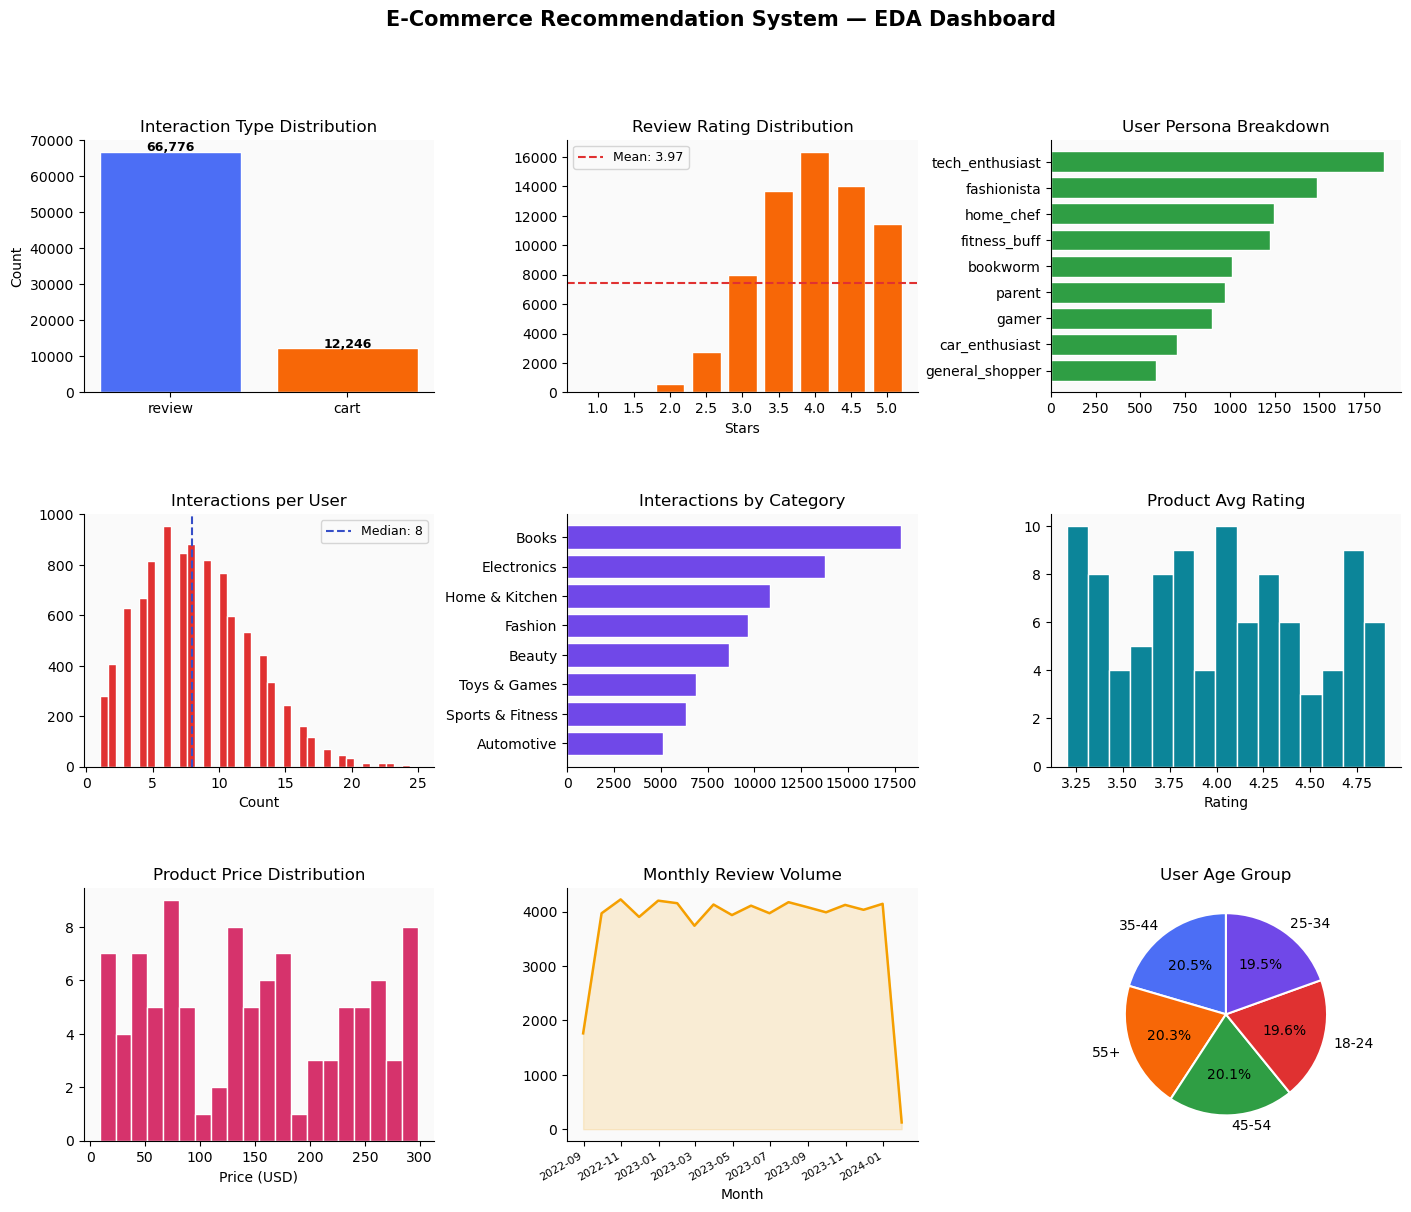

EDA chart saved → evaluation/eda_dashboard.png


In [9]:
uic = interactions_df.groupby('userId').size()
pic = interactions_df.groupby('productId').size()
n_u = interactions_df['userId'].nunique()
n_p = interactions_df['productId'].nunique()
pairs = interactions_df.groupby(['userId','productId']).ngroups
sparsity = 1 - pairs / (n_u * n_p)
cold_u   = (uic <= 2).sum()

print('='*58)
print('  EDA SUMMARY')
print('='*58)
print(f'  Total interactions      : {len(interactions_df):>9,}')
print(f'  Unique users            : {n_u:>9,}')
print(f'  Unique products         : {n_p:>9,}')
print(f'  Unique (user,product)   : {pairs:>9,}')
print(f'  Interaction matrix sparsity : {sparsity*100:>5.1f} %')
print(f'  Avg interactions/user   : {uic.mean():>8.1f}')
print(f'  Cold-start users (≤2)   : {cold_u:>9,}  ({100*cold_u/n_u:.1f} %)')
print(f'  Rating range (reviews)  : {reviews_df["rating"].min()} – {reviews_df["rating"].max()}')
print(f'  Avg rating              : {reviews_df["rating"].mean():>8.2f}')
print('='*58)

# ── EDA Dashboard: 9 panels ───────────────────────────────────────────────────
fig = plt.figure(figsize=(17, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

# 1. Interaction types
ax1 = fig.add_subplot(gs[0,0])
cnt = interactions_df['interaction'].value_counts()
bars = ax1.bar(cnt.index, cnt.values, color=PALETTE[:len(cnt)], edgecolor='white')
ax1.set_title('Interaction Type Distribution'); ax1.set_ylabel('Count')
for bar, v in zip(bars, cnt.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
             f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# 2. Rating distribution (reviews)
ax2 = fig.add_subplot(gs[0,1])
rv  = reviews_df['rating'].value_counts().sort_index()
ax2.bar(rv.index.astype(str), rv.values, color=PALETTE[1], edgecolor='white')
ax2.axhline(rv.mean(), color='#E03131', linestyle='--',
            label=f'Mean: {reviews_df["rating"].mean():.2f}')
ax2.set_title('Review Rating Distribution'); ax2.set_xlabel('Stars'); ax2.legend(fontsize=9)

# 3. User persona breakdown
ax3 = fig.add_subplot(gs[0,2])
persona = users_df['persona'].value_counts()
ax3.barh(persona.index, persona.values, color=PALETTE[2], edgecolor='white')
ax3.set_title('User Persona Breakdown'); ax3.invert_yaxis()

# 4. Interactions per user (power law)
ax4 = fig.add_subplot(gs[1,0])
ax4.hist(uic.values, bins=40, color=PALETTE[3], edgecolor='white')
ax4.axvline(uic.median(), color='#364FC7', linestyle='--', label=f'Median: {uic.median():.0f}')
ax4.set_title('Interactions per User'); ax4.set_xlabel('Count'); ax4.legend(fontsize=9)

# 5. Product interactions by category
ax5 = fig.add_subplot(gs[1,1])
merged = interactions_df.merge(products_df[['productId','category']], on='productId', how='left')
cat_cnt = merged['category'].value_counts()
ax5.barh(cat_cnt.index, cat_cnt.values, color=PALETTE[4], edgecolor='white')
ax5.set_title('Interactions by Category'); ax5.invert_yaxis()

# 6. Product avg rating distribution
ax6 = fig.add_subplot(gs[1,2])
ax6.hist(products_df['avgRating'], bins=15, color=PALETTE[5], edgecolor='white')
ax6.set_title('Product Avg Rating'); ax6.set_xlabel('Rating')

# 7. Price distribution
ax7 = fig.add_subplot(gs[2,0])
ax7.hist(products_df['price'], bins=20, color=PALETTE[6], edgecolor='white')
ax7.set_title('Product Price Distribution'); ax7.set_xlabel('Price (USD)')

# 8. Reviews over time
ax8 = fig.add_subplot(gs[2,1])
weekly = reviews_df.set_index('reviewedAt').resample('ME').size()
ax8.plot(weekly.index, weekly.values, color=PALETTE[7], linewidth=1.8)
ax8.fill_between(weekly.index, weekly.values, alpha=0.15, color=PALETTE[7])
ax8.set_title('Monthly Review Volume'); ax8.set_xlabel('Month')
plt.setp(ax8.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

# 9. User age group
ax9 = fig.add_subplot(gs[2,2])
age = users_df['age_group'].value_counts()
ax9.pie(age.values, labels=age.index, autopct='%1.1f%%',
        colors=PALETTE[:len(age)], startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':1.5})
ax9.set_title('User Age Group')

fig.suptitle('E-Commerce Recommendation System — EDA Dashboard',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation/eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA chart saved → evaluation/eda_dashboard.png')


Step 5 - Preprocessing and Scoring

Aggregated (user, product) pairs : 77,032
Non-zero scores                  : 62,059
Train interactions   : 63,217
Test interactions    : 15,805
Full matrix shape    : (9699, 100)
Train matrix shape   : (9699, 100)
Train nonzero entries: 49,329
Train sparsity       : 94.9 %
Test GT users        : 3,204


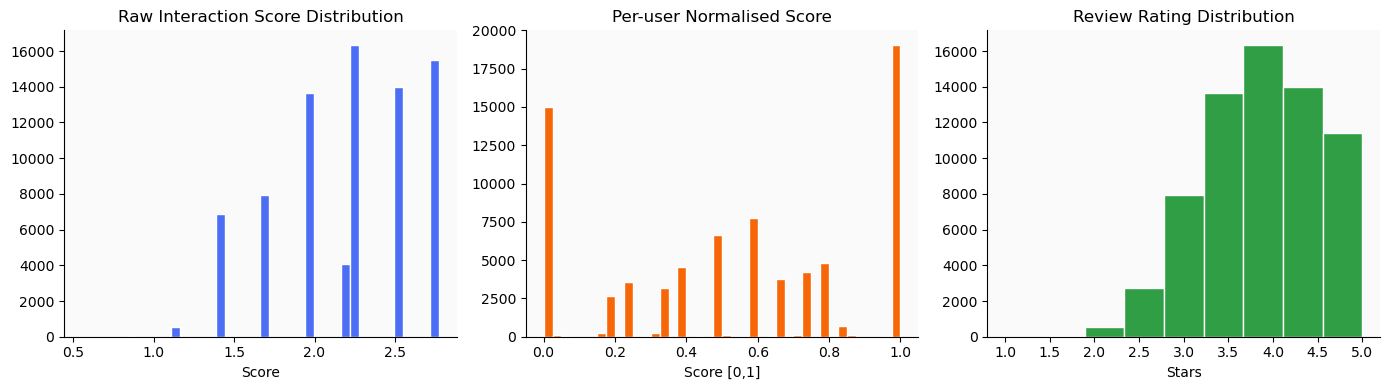

In [10]:
# ── Per-user min-max normalisation ───────────────────────────────────────────
def minmax_user(grp):
    mn, mx = grp.min(), grp.max()
    return (grp - mn) / (mx - mn + 1e-9)

# Aggregate: take max score when user interacted with same product multiple times
agg = interactions_df.groupby(['userId','productId'])['score'].max().reset_index()
agg.columns = ['userId', 'productId', 'implicit_score']
agg['implicit_score'] = agg.groupby('userId')['implicit_score'].transform(minmax_user)

print(f'Aggregated (user, product) pairs : {len(agg):,}')
print(f'Non-zero scores                  : {(agg["implicit_score"]>0).sum():,}')

# ── Time-based 80/20 train / test split ───────────────────────────────────────
# Sort by timestamp so we always train on past and test on future (no leakage)
interactions_sorted = interactions_df.sort_values('timestamp').reset_index(drop=True)
split_idx    = int(len(interactions_sorted) * (1 - CONFIG['test_size']))
train_raw    = interactions_sorted.iloc[:split_idx]
test_raw     = interactions_sorted.iloc[split_idx:]

# Build training aggregation
train_agg = train_raw.groupby(['userId','productId'])['score'].max().reset_index()
train_agg.columns = ['userId','productId','implicit_score']
train_agg['implicit_score'] = train_agg.groupby('userId')['implicit_score'].transform(minmax_user)

# ── Build user × product matrices ─────────────────────────────────────────────
ALL_USERS    = sorted(agg['userId'].unique().tolist())
ALL_PRODUCTS = sorted(agg['productId'].unique().tolist())
uid2idx      = {u: i for i, u in enumerate(ALL_USERS)}
pid2idx      = {p: i for i, p in enumerate(ALL_PRODUCTS)}

def build_matrix(df_agg, users, products, u2i, p2i):
    """Build dense float32 interaction matrix from aggregated dataframe."""
    mat = np.zeros((len(users), len(products)), dtype=np.float32)
    for uid, pid, sc in zip(df_agg['userId'], df_agg['productId'], df_agg['implicit_score']):
        i = u2i.get(uid)
        j = p2i.get(pid)
        if i is not None and j is not None:
            mat[i, j] = float(sc)
    return mat

full_matrix  = build_matrix(agg,       ALL_USERS, ALL_PRODUCTS, uid2idx, pid2idx)
train_matrix = build_matrix(train_agg, ALL_USERS, ALL_PRODUCTS, uid2idx, pid2idx)

# ── Seen products per user (exclusion list) ───────────────────────────────────
user_seen = agg.groupby('userId')['productId'].apply(set).to_dict()

# ── Test ground truth: reviews in test set (explicit preference signal) ────────
test_gt = (test_raw[test_raw['interaction'] == 'review']
           .groupby('userId')['productId'].apply(set).to_dict())

print(f'Train interactions   : {len(train_raw):,}')
print(f'Test interactions    : {len(test_raw):,}')
print(f'Full matrix shape    : {full_matrix.shape}')
print(f'Train matrix shape   : {train_matrix.shape}')
print(f'Train nonzero entries: {(train_matrix>0).sum():,}')
print(f'Train sparsity       : {(train_matrix==0).mean()*100:.1f} %')
print(f'Test GT users        : {len(test_gt):,}')

# Score distribution plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(interactions_df['score'], bins=40, color=PALETTE[0], edgecolor='white')
axes[0].set_title('Raw Interaction Score Distribution'); axes[0].set_xlabel('Score')
axes[1].hist(agg['implicit_score'], bins=40, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Per-user Normalised Score'); axes[1].set_xlabel('Score [0,1]')
axes[2].hist(reviews_df['rating'], bins=9, color=PALETTE[2], edgecolor='white')
axes[2].set_title('Review Rating Distribution'); axes[2].set_xlabel('Stars')
plt.tight_layout(); plt.show()


Step 6 - SVD Matrix Factorization

SVD complete
  User factors shape : (9699, 50)
  Item factors shape : (100, 50)
  Variance explained : 73.4% with 50 factors


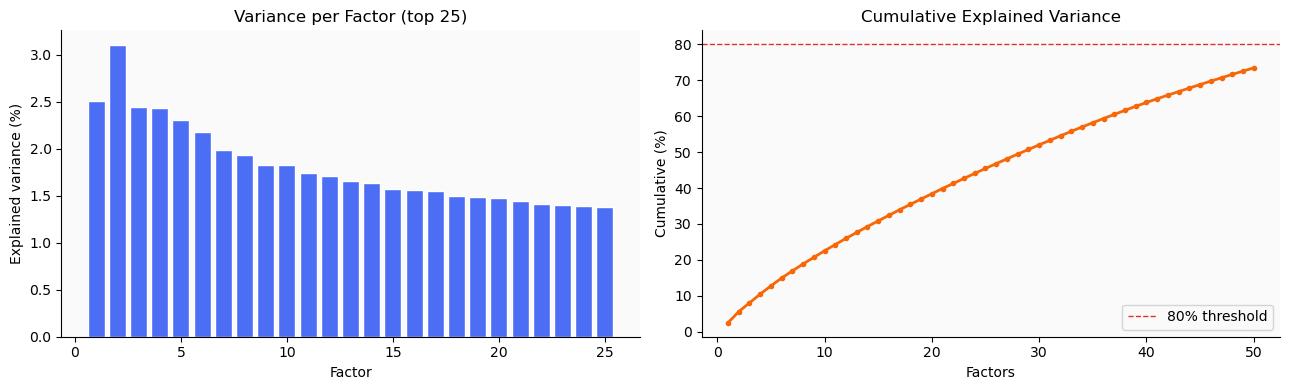

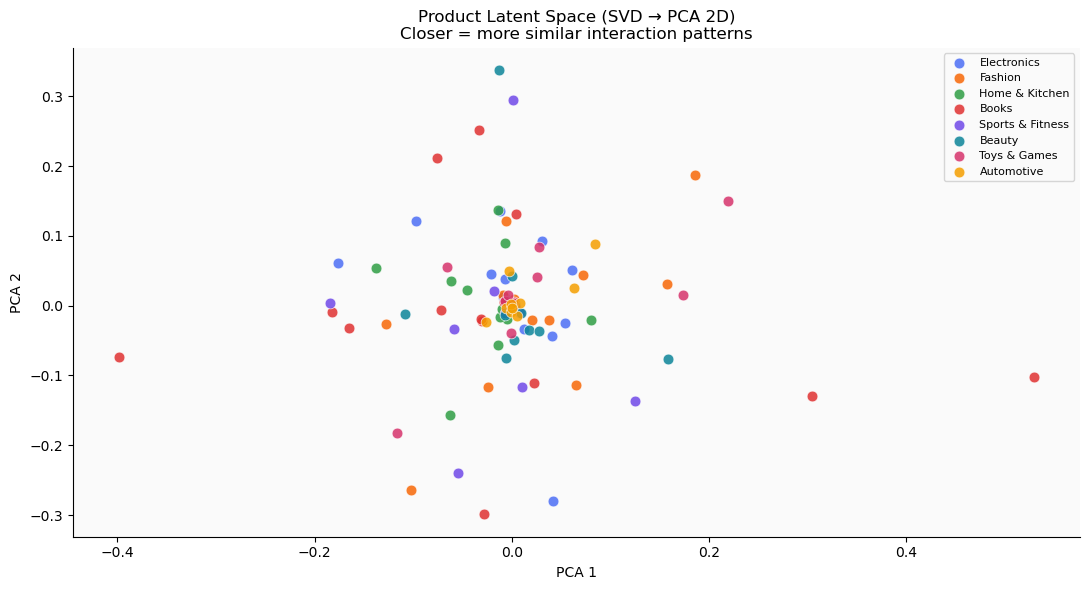

In [11]:
# Auto-cap factors to dataset size limits
max_possible = min(train_matrix.shape[0]-1, train_matrix.shape[1]-1, CONFIG['svd_factors'])
N_FACTORS    = max(5, max_possible)
if N_FACTORS < CONFIG['svd_factors']:
    print(f'[INFO] SVD factors capped: {CONFIG["svd_factors"]} → {N_FACTORS} (matrix size limit)')

svd_model    = TruncatedSVD(n_components=N_FACTORS, algorithm='randomized',
                             n_iter=10, random_state=CONFIG['random_seed'])
user_factors = svd_model.fit_transform(train_matrix)   # (n_users, k)
item_factors = svd_model.components_.T                  # (n_products, k)
explained_v  = svd_model.explained_variance_ratio_

print(f'SVD complete')
print(f'  User factors shape : {user_factors.shape}')
print(f'  Item factors shape : {item_factors.shape}')
print(f'  Variance explained : {explained_v.sum()*100:.1f}% with {N_FACTORS} factors')

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
top = min(25, N_FACTORS)
axes[0].bar(range(1,top+1), explained_v[:top]*100, color=PALETTE[0], edgecolor='white')
axes[0].set_title(f'Variance per Factor (top {top})')
axes[0].set_xlabel('Factor'); axes[0].set_ylabel('Explained variance (%)')

cum = np.cumsum(explained_v)
axes[1].plot(range(1,N_FACTORS+1), cum*100, color=PALETTE[1], linewidth=2, marker='o', markersize=3)
axes[1].axhline(80, color='#E03131', linestyle='--', linewidth=1, label='80% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Factors'); axes[1].set_ylabel('Cumulative (%)'); axes[1].legend()
plt.tight_layout(); plt.show()

# 2D projection of item latent space coloured by category
if N_FACTORS >= 2:
    pca_2d  = PCA(n_components=2, random_state=42)
    items2d = pca_2d.fit_transform(item_factors)
    cats     = products_df['category'].values
    uniq_c   = list(dict.fromkeys(cats))
    fig, ax  = plt.subplots(figsize=(11, 6))
    for i, cat in enumerate(uniq_c):
        mask = cats == cat
        ax.scatter(items2d[mask,0], items2d[mask,1], c=PALETTE[i%len(PALETTE)],
                   label=cat, s=60, alpha=0.85, edgecolors='white', linewidths=0.5)
    ax.set_title('Product Latent Space (SVD → PCA 2D)\nCloser = more similar interaction patterns')
    ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
    ax.legend(loc='best', fontsize=8, framealpha=0.8)
    plt.tight_layout(); plt.show()


SVD Matrix Factorization++

Training SVD++ ...
  Epoch  5/20  RMSE = 0.23253
  Epoch 10/20  RMSE = 0.22803
  Epoch 15/20  RMSE = 0.22470
  Epoch 20/20  RMSE = 0.22218
SVD++ trained in 49.8s


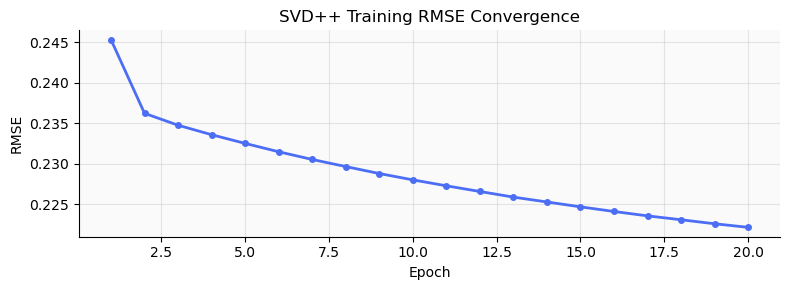


SVD++ sample recommendations:
  user_00001 (bookworm, seen=7):
    prod_0078  Beauty              Lip Balm Set
    prod_0068  Sports & Fitness    Gym Gloves
    prod_0045  Home & Kitchen      Mixing Bowl Set
  user_00002 (fashionista, seen=4):
    prod_0078  Beauty              Lip Balm Set
    prod_0068  Sports & Fitness    Gym Gloves
    prod_0045  Home & Kitchen      Mixing Bowl Set
  user_00003 (general_shopper, seen=13):
    prod_0078  Beauty              Lip Balm Set
    prod_0068  Sports & Fitness    Gym Gloves
    prod_0045  Home & Kitchen      Mixing Bowl Set


In [12]:
# ════════════════════════════════════════════════════════════════════
#  SVD++  —  Matrix Factorization with Implicit Feedback
#  Trained with Stochastic Gradient Descent (SGD)
# ════════════════════════════════════════════════════════════════════

# ── Add SVD++ hyperparameters to CONFIG (add these to Cell 3 CONFIG dict,
#    or they will be defaulted safely here) ──────────────────────────────────
CONFIG.setdefault('svdpp_factors', 20)   # latent dimensions (keep ≤ svd_factors)
CONFIG.setdefault('svdpp_epochs',  20)   # SGD epochs
CONFIG.setdefault('svdpp_lr',      0.005) # learning rate
CONFIG.setdefault('svdpp_reg',     0.02)  # L2 regularisation

print('Training SVD++ ...')
t_start = time.time()

N_USERS    = len(ALL_USERS)
N_PRODUCTS = len(ALL_PRODUCTS)

K_PP   = min(CONFIG['svdpp_factors'], N_USERS - 1, N_PRODUCTS - 1)
N_E_PP = CONFIG['svdpp_epochs']
LR_PP  = CONFIG['svdpp_lr']
REG_PP = CONFIG['svdpp_reg']

# Global mean of non-zero training scores
_nonzero_mask = train_matrix > 0
MU_GLOBAL = float(train_matrix[_nonzero_mask].mean()) if _nonzero_mask.any() else 0.5

# ── Build implicit neighbourhood lookup: user_index → array of item indices ──
#    Uses the same train_matrix that SVD and KNN already use.
user_implicit_items = {}
for _u in range(N_USERS):
    _items = np.where(train_matrix[_u] > 0)[0]
    if len(_items):
        user_implicit_items[_u] = _items.astype(np.int32)

# ── Also build a string-keyed "seen in train" lookup (mirrors user_seen) ─────
#    Required by the evaluation cell (build_binary_labels) which calls
#    user_seen_train.get(str(uid), set())
user_seen_train = {
    ALL_USERS[_u]: set(ALL_PRODUCTS[_j] for _j in idxs)
    for _u, idxs in user_implicit_items.items()
}

# ── Initialise parameters ────────────────────────────────────────────────────
np.random.seed(CONFIG['random_seed'])
P_pp  = np.random.normal(0, 0.01, (N_USERS,    K_PP)).astype(np.float32)  # user latent
Q_pp  = np.random.normal(0, 0.01, (N_PRODUCTS, K_PP)).astype(np.float32)  # item latent
Y_pp  = np.random.normal(0, 0.01, (N_PRODUCTS, K_PP)).astype(np.float32)  # implicit-item (SVD++ key)
bu_pp = np.zeros(N_USERS,    dtype=np.float32)   # user bias
bi_pp = np.zeros(N_PRODUCTS, dtype=np.float32)   # item bias

# ── Build training pairs array once ──────────────────────────────────────────
#    Each row: [user_index, item_index, score]
_ui, _ii = np.where(train_matrix > 0)
train_pairs_arr = np.column_stack([_ui, _ii, train_matrix[_ui, _ii]]).astype(np.float32)

# ── Training loop (SGD) ──────────────────────────────────────────────────────
pp_losses = []
for epoch in range(N_E_PP):
    np.random.shuffle(train_pairs_arr)
    total_loss = 0.0

    for row in train_pairs_arr:
        u, i, r = int(row[0]), int(row[1]), float(row[2])

        Iu   = user_implicit_items.get(u, np.array([], dtype=np.int32))
        norm = len(Iu) ** -0.5 if len(Iu) > 0 else 0.0

        # SVD++ augmented user vector: pᵤ + |N(u)|⁻⁰·⁵ · Σⱼ yⱼ
        implicit_sum = Y_pp[Iu].sum(axis=0) if len(Iu) > 0 else np.zeros(K_PP, dtype=np.float32)
        pu_plus = P_pp[u] + norm * implicit_sum

        # Predicted score
        r_hat = MU_GLOBAL + bu_pp[u] + bi_pp[i] + np.dot(pu_plus, Q_pp[i])
        err   = r - r_hat
        total_loss += err * err

        # SGD updates
        bu_pp[u] += LR_PP * (err - REG_PP * bu_pp[u])
        bi_pp[i] += LR_PP * (err - REG_PP * bi_pp[i])
        qi        = Q_pp[i].copy()
        P_pp[u]  += LR_PP * (err * qi      - REG_PP * P_pp[u])
        Q_pp[i]  += LR_PP * (err * pu_plus - REG_PP * Q_pp[i])
        if len(Iu) > 0:
            Y_pp[Iu] += LR_PP * (err * norm * qi - REG_PP * Y_pp[Iu])

    rmse = np.sqrt(total_loss / len(train_pairs_arr))
    pp_losses.append(rmse)
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1:2d}/{N_E_PP}  RMSE = {rmse:.5f}')

elapsed_pp = time.time() - t_start
print(f'SVD++ trained in {elapsed_pp:.1f}s')

# ── RMSE convergence plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, N_E_PP + 1), pp_losses,
        color=PALETTE[0], linewidth=2, marker='o', markersize=4)
ax.set_title('SVD++ Training RMSE Convergence')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Predict function ──────────────────────────────────────────────────────────
def svdpp_predict(user_id, top_n=None):
    """
    Get SVD++ recommendations for a user.

    Parameters
    ----------
    user_id : str   — matches userId in users.csv
    top_n   : int   — number of items to return (default CONFIG['top_n'])

    Returns
    -------
    list of productId strings sorted by predicted score descending,
    excluding products already seen in training.
    """
    if top_n is None:
        top_n = CONFIG['top_n']

    uidx = uid2idx.get(str(user_id))
    if uidx is None:
        return []   # unseen user → empty; fall back to popularity in hybrid

    Iu   = user_implicit_items.get(uidx, np.array([], dtype=np.int32))
    norm = len(Iu) ** -0.5 if len(Iu) > 0 else 0.0
    implicit_sum = Y_pp[Iu].sum(axis=0) if len(Iu) > 0 else np.zeros(K_PP, dtype=np.float32)
    pu_plus = P_pp[uidx] + norm * implicit_sum

    # Score all products: µ + bu + bi + pu_plus · Q^T
    scores = MU_GLOBAL + bu_pp[uidx] + bi_pp + Q_pp @ pu_plus

    seen  = user_seen_train.get(str(user_id), set())
    order = np.argsort(scores)[::-1]
    return [ALL_PRODUCTS[j] for j in order if ALL_PRODUCTS[j] not in seen][:top_n]

# ── Quick demo ────────────────────────────────────────────────────────────────
print('\nSVD++ sample recommendations:')
for uid in ALL_USERS[:3]:
    recs = svdpp_predict(uid, top_n=3)
    urow = users_df[users_df['userId'] == uid]
    p    = urow['persona'].values[0] if len(urow) else 'n/a'
    seen_n = len(user_seen_train.get(str(uid), set()))
    print(f'  {uid} ({p}, seen={seen_n}):')
    for pid in recs:
        row  = products_df[products_df['productId'] == pid]
        name = row['name'].values[0]     if len(row) else pid
        cat  = row['category'].values[0] if len(row) else ''
        print(f'    {pid}  {cat:18s}  {name[:40]}')

LightFM Style 


Building feature matrices ...
  User feature matrix : (9699, 9)  (one-hot persona)
  Item feature matrix : (100, 300)  (TF-IDF: name+category+tags)
  Popularity scores   : 100 products

Training LightFM-Hybrid (20 epochs × 5000 pairs) ...
  Epoch  5/20  BPR loss = 0.59170
  Epoch 10/20  BPR loss = 0.57144
  Epoch 15/20  BPR loss = 0.55747
  Epoch 20/20  BPR loss = 0.54836
LightFM-Hybrid trained in 13.6s


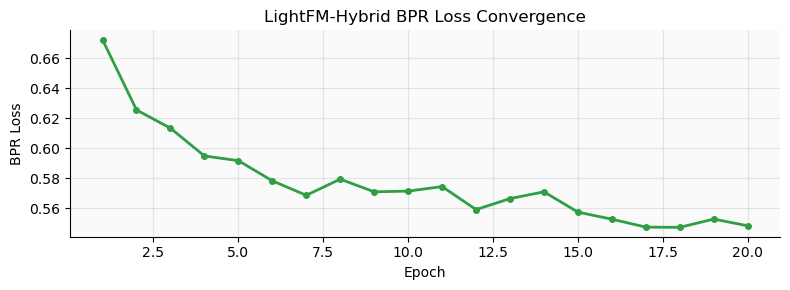


LightFM-Hybrid sample recommendations:
  user_00001 (bookworm, seen=7):
    prod_0060  Books               The Lean Startup
    prod_0055  Books               Thinking Fast Slow
    prod_0051  Books               Project Hail Mary
  user_00002 (fashionista, seen=4):
    prod_0076  Beauty              Hair Diffuser
    prod_0017  Fashion             Running Sneakers
    prod_0020  Fashion             Formal Shirt
  user_00003 (general_shopper, seen=13):
    prod_0076  Beauty              Hair Diffuser
    prod_0071  Beauty              Face Serum Vitamin C
    prod_0075  Beauty              Beard Trimmer


In [13]:
# ════════════════════════════════════════════════════════════════════
#  LightFM-style Hybrid Model
#  BPR training: push score(u, positive) > score(u, negative)
# ════════════════════════════════════════════════════════════════════

# ── Dependency guard: must run Cells 3 → 15 first ───────────────────────────
_missing = [v for v in ('ALL_USERS', 'ALL_PRODUCTS', 'train_matrix', 'train_agg',
                         'uid2idx', 'pid2idx', 'CONFIG', 'PALETTE',
                         'users_df', 'products_df', 'user_seen_train')
            if v not in dir()]
if _missing:
    raise RuntimeError(
        f"LightFM cell requires these variables which are not yet defined: {_missing}\n"
        "Please run Cells 3 (imports/config), 5 (data load), 11 (preprocessing/matrices), "
        "13 (SVD), and 15 (SVD++) first, then re-run this cell."
    )

# ── Add LightFM hyperparameters to CONFIG (or set defaults safely) ───────────
CONFIG.setdefault('lfm_factors', 20)    # latent dimensions
CONFIG.setdefault('lfm_epochs',  20)    # BPR training epochs
CONFIG.setdefault('lfm_lr',      0.05)  # learning rate
CONFIG.setdefault('lfm_reg',     0.01)  # L2 regularisation
CONFIG.setdefault('lfm_pairs',  5000)   # BPR pairs sampled per epoch

# ── Add LabelEncoder import if not already present ───────────────────────────
from sklearn.preprocessing import LabelEncoder

print('Building feature matrices ...')

N_USERS    = len(ALL_USERS)
N_PRODUCTS = len(ALL_PRODUCTS)

# ── User feature matrix: one-hot persona encoding ────────────────────────────
le_persona    = LabelEncoder()
le_persona.fit(users_df['persona'].fillna('unknown'))
N_PERSONA     = len(le_persona.classes_)
user_feat_mat = np.zeros((N_USERS, N_PERSONA), dtype=np.float32)
for _uid_str in ALL_USERS:
    _row = users_df[users_df['userId'] == _uid_str]
    if len(_row):
        _code = le_persona.transform([_row['persona'].values[0]])[0]
        user_feat_mat[uid2idx[_uid_str], _code] = 1.0
print(f'  User feature matrix : {user_feat_mat.shape}  (one-hot persona)')

# ── Item feature matrix: TF-IDF on name + category + tags ───────────────────
#    NOTE: tfidf_vec, tfidf_matrix, content_sim, tfidf_pid2idx and
#    popularity_scores are built here (same logic as Cell 19 — Content-Based).
#    If Cell 19 has already run, this safely overwrites with identical values.
def _parse_tags(t):
    if pd.isna(t): return ''
    return ' '.join(re.findall(r"'([^']+)'", str(t)))

products_df['tags_clean']   = products_df['tags'].apply(_parse_tags)
products_df['text_feature'] = (
    products_df['name'].fillna('')     + ' ' +
    products_df['category'].fillna('') + ' ' +
    products_df['tags_clean']
)

tfidf_vec     = TfidfVectorizer(max_features=300, stop_words='english',
                                 ngram_range=(1, 2), sublinear_tf=True)
tfidf_matrix  = tfidf_vec.fit_transform(products_df['text_feature'])
content_sim   = cosine_similarity(tfidf_matrix, tfidf_matrix)
tfidf_pids    = products_df['productId'].tolist()
tfidf_pid2idx = {p: i for i, p in enumerate(tfidf_pids)}

# Map TF-IDF rows into ALL_PRODUCTS order
N_ITEM_FEAT  = tfidf_matrix.shape[1]
item_feat_mat = np.zeros((N_PRODUCTS, N_ITEM_FEAT), dtype=np.float32)
for _j, _pid in enumerate(ALL_PRODUCTS):
    _idx = products_df.index[products_df['productId'] == _pid]
    if len(_idx):
        item_feat_mat[_j] = tfidf_matrix[_idx[0]].toarray().flatten()
print(f'  Item feature matrix : {item_feat_mat.shape}  (TF-IDF: name+category+tags)')

# ── Popularity scores ────────────────────────────────────────────────────────
#    Also used by Cell 19 / Cell 21 recommend() — safe to redefine here.
_rv = products_df['avgRating'].fillna(3.0).values.reshape(-1, 1)
_nv = np.log1p(products_df['numReviews'].fillna(0).values.reshape(-1, 1))
_pp = _rv * _nv
products_df['pop_score'] = (_pp / (_pp.max() + 1e-9)).flatten()
popularity_scores = dict(zip(products_df['productId'], products_df['pop_score']))
pop_arr = np.array([popularity_scores.get(p, 0.0) for p in ALL_PRODUCTS], dtype=np.float32)
print(f'  Popularity scores   : {len(popularity_scores)} products')

# ── Build training pairs array from train_matrix ─────────────────────────────
#    (same variable name as SVD++ cell so they share the same pairs)
_ui_lfm, _ii_lfm = np.where(train_matrix > 0)
train_pairs_arr = np.column_stack(
    [_ui_lfm, _ii_lfm, train_matrix[_ui_lfm, _ii_lfm]]
).astype(np.float32)

# ── Observed set for fast negative sampling ───────────────────────────────────
observed_set = set(zip(_ui_lfm.tolist(), _ii_lfm.tolist()))

# ── Initialise LightFM parameters ────────────────────────────────────────────
K_FM  = min(CONFIG['lfm_factors'], N_USERS - 1, N_PRODUCTS - 1)
LR_FM = CONFIG['lfm_lr']
REG_FM= CONFIG['lfm_reg']
N_EFM = CONFIG['lfm_epochs']
N_PFM = CONFIG['lfm_pairs']   # pairs sampled per epoch

np.random.seed(CONFIG['random_seed'])
U_emb_fm = np.random.normal(0, 0.01, (N_USERS,    K_FM)).astype(np.float32)  # collaborative user
I_emb_fm = np.random.normal(0, 0.01, (N_PRODUCTS, K_FM)).astype(np.float32)  # collaborative item
W_uf     = np.random.normal(0, 0.01, (N_PERSONA,   K_FM)).astype(np.float32)  # user feature proj
W_if     = np.random.normal(0, 0.01, (N_ITEM_FEAT, K_FM)).astype(np.float32)  # item feature proj
bu_fm    = np.zeros(N_USERS,    dtype=np.float32)
bi_fm    = np.zeros(N_PRODUCTS, dtype=np.float32)

def _sigmoid_fm(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -10, 10)))

# ── BPR Training loop ─────────────────────────────────────────────────────────
print(f'\nTraining LightFM-Hybrid ({N_EFM} epochs × {N_PFM} pairs) ...')
t_start  = time.time()
fm_losses = []
_n_pairs  = len(train_pairs_arr)

for epoch in range(N_EFM):
    np.random.shuffle(train_pairs_arr)
    epoch_loss = 0.0
    count      = 0

    for _row in train_pairs_arr[:min(N_PFM, _n_pairs)]:
        u, i = int(_row[0]), int(_row[1])

        # Combined user & positive-item vectors
        pu = U_emb_fm[u] + user_feat_mat[u] @ W_uf
        qi = I_emb_fm[i] + item_feat_mat[i] @ W_if

        # Negative item sample (uniform, skip observed)
        j = np.random.randint(N_PRODUCTS)
        _attempts = 0
        while (u, j) in observed_set and _attempts < 30:
            j = np.random.randint(N_PRODUCTS)
            _attempts += 1
        qj = I_emb_fm[j] + item_feat_mat[j] @ W_if

        # BPR loss: maximise score(pos) − score(neg)
        s_pos = bu_fm[u] + bi_fm[i] + np.dot(pu, qi)
        s_neg = bu_fm[u] + bi_fm[j] + np.dot(pu, qj)
        diff  = s_pos - s_neg
        grad  = _sigmoid_fm(-diff)          # ∂BPR/∂diff = σ(−diff)
        epoch_loss -= np.log(_sigmoid_fm(diff) + 1e-9)
        count += 1

        # Bias updates
        bu_fm[u] += LR_FM * (grad - REG_FM * bu_fm[u])
        bi_fm[i] += LR_FM * (grad - REG_FM * bi_fm[i])
        bi_fm[j] -= LR_FM * (grad + REG_FM * bi_fm[j])

        # Embedding updates
        U_emb_fm[u] += LR_FM * (grad * (qi - qj)  - REG_FM * U_emb_fm[u])
        I_emb_fm[i] += LR_FM * (grad * pu          - REG_FM * I_emb_fm[i])
        I_emb_fm[j] -= LR_FM * (grad * pu          + REG_FM * I_emb_fm[j])

        # Feature projection updates
        W_uf += LR_FM * (grad * np.outer(user_feat_mat[u], qi - qj) - REG_FM * W_uf)
        W_if += LR_FM * (grad * (np.outer(item_feat_mat[i], pu)
                               - np.outer(item_feat_mat[j], pu))    - REG_FM * W_if)

    avg_loss = epoch_loss / (count + 1e-9)
    fm_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1:2d}/{N_EFM}  BPR loss = {avg_loss:.5f}')

elapsed_fm = time.time() - t_start
print(f'LightFM-Hybrid trained in {elapsed_fm:.1f}s')

# ── BPR loss convergence plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, N_EFM + 1), fm_losses,
        color=PALETTE[2], linewidth=2, marker='o', markersize=4)
ax.set_title('LightFM-Hybrid BPR Loss Convergence')
ax.set_xlabel('Epoch')
ax.set_ylabel('BPR Loss')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Predict function ──────────────────────────────────────────────────────────
def lightfm_predict(user_id, top_n=None):
    """
    Get LightFM hybrid recommendations for a user.

    Parameters
    ----------
    user_id : str   — matches userId in users.csv
    top_n   : int   — number of items to return (default CONFIG['top_n'])

    Returns
    -------
    list of productId strings sorted by predicted score descending,
    excluding products already seen in training.
    Cold-start friendly: persona features contribute even with no interactions.
    """
    if top_n is None:
        top_n = CONFIG['top_n']

    uidx = uid2idx.get(str(user_id))
    if uidx is None:
        return []   # completely unknown user → fall back to popularity in hybrid

    pu      = U_emb_fm[uidx] + user_feat_mat[uidx] @ W_uf
    qi_all  = I_emb_fm + item_feat_mat @ W_if   # (N_PRODUCTS, K_FM)
    scores  = bu_fm[uidx] + bi_fm + qi_all @ pu

    seen  = user_seen_train.get(str(user_id), set())
    order = np.argsort(scores)[::-1]
    return [ALL_PRODUCTS[j] for j in order if ALL_PRODUCTS[j] not in seen][:top_n]

# ── Quick demo ────────────────────────────────────────────────────────────────
print('\nLightFM-Hybrid sample recommendations:')
for uid in ALL_USERS[:3]:
    recs = lightfm_predict(uid, top_n=3)
    urow = users_df[users_df['userId'] == uid]
    p    = urow['persona'].values[0] if len(urow) else 'n/a'
    seen_n = len(user_seen_train.get(str(uid), set()))
    print(f'  {uid} ({p}, seen={seen_n}):')
    for pid in recs:
        row  = products_df[products_df['productId'] == pid]
        name = row['name'].values[0]     if len(row) else pid
        cat  = row['category'].values[0] if len(row) else ''
        print(f'    {pid}  {cat:18s}  {name[:40]}')

Step 7 - KNN - User Based and Item Based Collaborative Filtering

User-based KNN fitted  (K=20, metric=cosine, n_users=9,699)
Item-based KNN fitted  (K=20, metric=cosine, n_products=100)

5 most similar users to [user_00001] (bookworm, Sydney)
  user_07383  sim=78.2%  persona=bookworm              age=55+
  user_00634  sim=73.9%  persona=parent                age=18-24
  user_03512  sim=72.9%  persona=home_chef             age=25-34
  user_02759  sim=72.8%  persona=bookworm              age=18-24
  user_08534  sim=72.5%  persona=home_chef             age=55+


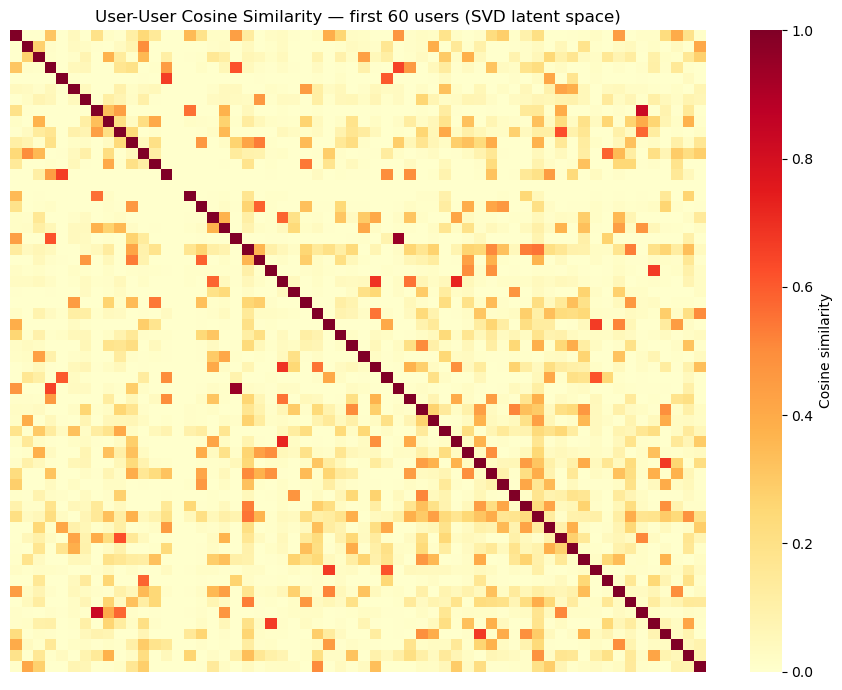

In [19]:
K_user = min(CONFIG['knn_k'], len(ALL_USERS)-1)
K_item = min(CONFIG['knn_k'], len(ALL_PRODUCTS)-1)

knn_user = NearestNeighbors(n_neighbors=K_user+1, metric='cosine',
                             algorithm='brute', n_jobs=-1)
knn_user.fit(user_factors)
print(f'User-based KNN fitted  (K={K_user}, metric=cosine, n_users={len(ALL_USERS):,})')

knn_item = NearestNeighbors(n_neighbors=K_item+1, metric='cosine',
                             algorithm='brute', n_jobs=-1)
knn_item.fit(item_factors)
print(f'Item-based KNN fitted  (K={K_item}, metric=cosine, n_products={len(ALL_PRODUCTS)})')

def user_based_cf_scores(user_idx):
    """Score all products via weighted average of K nearest-user interactions."""
    vec            = user_factors[user_idx].reshape(1, -1)
    dists, nb_idx  = knn_user.kneighbors(vec)
    dists, nb_idx  = dists[0], nb_idx[0]
    mask           = nb_idx != user_idx      # exclude self
    dists, nb_idx  = dists[mask], nb_idx[mask]
    sims           = np.clip(1 - dists, 0, 1)
    scores         = np.dot(sims, train_matrix[nb_idx])
    return scores / (sims.sum() + 1e-9)

def item_based_cf_scores(user_idx):
    """Score all products via KNN of items the user has interacted with."""
    user_row  = train_matrix[user_idx]
    pos_items = np.where(user_row > 0)[0]
    if not len(pos_items):
        return np.zeros(len(ALL_PRODUCTS), dtype=np.float32)
    scores = np.zeros(len(ALL_PRODUCTS), dtype=np.float32)
    for item_idx in pos_items:
        vec = item_factors[item_idx].reshape(1, -1)
        dists, nb_idx = knn_item.kneighbors(vec)
        dists, nb_idx = dists[0][1:], nb_idx[0][1:]    # skip self
        sims  = np.clip(1 - dists, 0, 1)
        scores[nb_idx] += sims * user_row[item_idx]
    return scores

# ── Demo: inspect nearest neighbours ──────────────────────────────────────────
demo_uid  = ALL_USERS[0]
demo_idx  = uid2idx[demo_uid]
demo_urow = users_df[users_df['userId']==demo_uid].iloc[0]
print(f'\n5 most similar users to [{demo_uid}] ({demo_urow["persona"]}, {demo_urow["city"]})')
vec = user_factors[demo_idx].reshape(1,-1)
d, nb = knn_user.kneighbors(vec)
for i in range(1, 6):
    u2   = ALL_USERS[nb[0][i]]
    sim  = (1 - d[0][i]) * 100
    urow = users_df[users_df['userId']==u2]
    p    = urow['persona'].values[0] if len(urow) else 'n/a'
    ag   = urow['age_group'].values[0] if len(urow) else 'n/a'
    print(f'  {u2}  sim={sim:.1f}%  persona={p:20s}  age={ag}')

# User similarity heatmap (first 60 users)
n_heat = min(60, len(user_factors))
sim_h  = cosine_similarity(user_factors[:n_heat])
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(sim_h, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
            xticklabels=False, yticklabels=False,
            cbar_kws={'label':'Cosine similarity'})
ax.set_title(f'User-User Cosine Similarity — first {n_heat} users (SVD latent space)')
plt.tight_layout(); plt.show()


Step 8 - Content Based Filter

In [17]:
# ── Parse tags: "['electronics', 'wireless']" → "electronics wireless" ─────
def parse_tags(tag_str):
    if pd.isna(tag_str): return ''
    return ' '.join(re.findall(r"'([^']+)'", str(tag_str)))

products_df['tags_clean']   = products_df['tags'].apply(parse_tags)
products_df['text_feature'] = (
    products_df['name'].fillna('')      + ' ' +
    products_df['category'].fillna('')  + ' ' +
    products_df['tags_clean']
)

# TF-IDF vectoriser
tfidf_vec    = TfidfVectorizer(max_features=300, stop_words='english',
                                ngram_range=(1,2), sublinear_tf=True)
tfidf_matrix = tfidf_vec.fit_transform(products_df['text_feature'])
content_sim  = cosine_similarity(tfidf_matrix, tfidf_matrix)
tfidf_pids   = products_df['productId'].tolist()
tfidf_pid2idx = {p: i for i, p in enumerate(tfidf_pids)}

print(f'TF-IDF matrix : {tfidf_matrix.shape}')
print(f'Content sim   : {content_sim.shape}')

# ── Popularity score: avgRating × log(1+numReviews) ──────────────────────────
rv_ = products_df['avgRating'].fillna(3.0).values.reshape(-1,1)
nv_ = np.log1p(products_df['numReviews'].fillna(0).values.reshape(-1,1))
pp_ = rv_ * nv_
products_df['pop_score'] = (pp_ / (pp_.max() + 1e-9)).flatten()
popularity_scores = dict(zip(products_df['productId'], products_df['pop_score']))

print('Popularity scores computed')
print(f'Top-5 most popular products:')
top_pop = sorted(popularity_scores.items(), key=lambda x: x[1], reverse=True)[:5]
for pid, sc in top_pop:
    row = products_df[products_df['productId']==pid].iloc[0]
    print(f'  {pid}  pop={sc:.4f}  {row["category"]:18s}  {row["name"][:40]}')

def content_based_scores(interacted_pids, exclude=None):
    """Aggregate TF-IDF similarity scores from user's seen products."""
    exclude   = exclude or set()
    score_agg = np.zeros(len(tfidf_pids), dtype=np.float32)
    for pid in interacted_pids:
        i = tfidf_pid2idx.get(pid)
        if i is not None:
            score_agg += content_sim[i]
    # Zero out seen and excluded products
    for pid in list(interacted_pids) + list(exclude):
        j = tfidf_pid2idx.get(pid)
        if j is not None:
            score_agg[j] = 0.0
    return {tfidf_pids[i]: float(score_agg[i]) for i in range(len(tfidf_pids))}

# Demo: find similar products
sample_pid  = products_df['productId'].iloc[0]
sample_name = products_df.loc[products_df['productId']==sample_pid,'name'].values[0]
cb_scores   = content_based_scores([sample_pid])
top5_cb     = sorted(cb_scores.items(), key=lambda x: x[1], reverse=True)[:5]
print(f'\nTop-5 similar to [{sample_pid}] "{sample_name}":')
for pid, sc in top5_cb:
    row = products_df[products_df['productId']==pid].iloc[0]
    print(f'  {pid}  sim={sc:.4f}  {row["category"]:18s}  {row["name"][:40]}')


TF-IDF matrix : (100, 300)
Content sim   : (100, 100)
Popularity scores computed
Top-5 most popular products:
  prod_0045  pop=1.0000  Home & Kitchen      Mixing Bowl Set
  prod_0016  pop=0.9971  Fashion             Slim-Fit Jeans
  prod_0020  pop=0.9539  Fashion             Formal Shirt
  prod_0062  pop=0.9391  Sports & Fitness    Resistance Bands (set)
  prod_0022  pop=0.9379  Fashion             Ankle Boots

Top-5 similar to [prod_0001] "Wireless Earbuds":
  prod_0002  sim=0.1989  Electronics         Bluetooth Speaker
  prod_0004  sim=0.1989  Electronics         Mechanical Keyboard
  prod_0012  sim=0.1989  Electronics         Laptop Stand
  prod_0013  sim=0.1989  Electronics         Raspberry Pi 4
  prod_0010  sim=0.1820  Electronics         Gaming Mouse


Step 9 - Hybrid Ensemble

In [20]:
def get_weights(n_interactions):
    """Return adaptive blend weights based on user interaction count."""
    if n_interactions < 3:
        return {'user_cf': 0.05, 'item_cf': 0.05, 'content': 0.30, 'popularity': 0.60}
    elif n_interactions < 10:
        return {'user_cf': 0.25, 'item_cf': 0.25, 'content': 0.30, 'popularity': 0.20}
    else:
        return {'user_cf': 0.40, 'item_cf': 0.35, 'content': 0.20, 'popularity': 0.05}

def recommend(user_id, top_n=None, weights=None):
    """
    Generate top-N product recommendations for a user.

    Parameters
    ----------
    user_id : str   — matches userId in users.csv (e.g. 'user_00001')
    top_n   : int   — number of recommendations (default CONFIG['top_n'])
    weights : dict  — override adaptive weights (optional)

    Returns
    -------
    list of dicts: [{'productId', 'name', 'category', 'price',
                     'avgRating', 'score', 'reason', 'coldStart'}]
    """
    if top_n is None:
        top_n = CONFIG['top_n']

    user_id  = str(user_id)
    user_idx = uid2idx.get(user_id)
    seen     = user_seen.get(user_id, set())
    is_cold  = len(seen) < 3
    w        = weights or get_weights(len(seen))
    scores   = defaultdict(float)
    reason   = {}

    # ── User-based CF ──────────────────────────────────────────────────────
    if user_idx is not None and w['user_cf'] > 0:
        ucf   = user_based_cf_scores(user_idx)
        max_s = ucf.max() + 1e-9
        for j, s in enumerate(ucf):
            if s > 0:
                p = ALL_PRODUCTS[j]
                scores[p] += w['user_cf'] * (s / max_s)
                reason.setdefault(p, 'user_cf')

    # ── Item-based CF ──────────────────────────────────────────────────────
    if user_idx is not None and w['item_cf'] > 0:
        icf   = item_based_cf_scores(user_idx)
        max_s = icf.max() + 1e-9
        for j, s in enumerate(icf):
            if s > 0:
                p = ALL_PRODUCTS[j]
                scores[p] += w['item_cf'] * (s / max_s)
                reason.setdefault(p, 'item_cf')

    # ── Content-based ──────────────────────────────────────────────────────
    if w['content'] > 0 and len(seen) > 0:
        cb    = content_based_scores(list(seen)[:30])
        max_s = max(cb.values()) + 1e-9 if cb else 1
        for p, s in cb.items():
            scores[p] += w['content'] * (s / max_s)
            reason.setdefault(p, 'content')

    # ── Popularity ─────────────────────────────────────────────────────────
    if w['popularity'] > 0:
        for p, s in popularity_scores.items():
            if p not in seen:
                scores[p] += w['popularity'] * s
                reason.setdefault(p, 'popularity')

    # ── Remove already-seen products ───────────────────────────────────────
    for p in seen:
        scores.pop(p, None)

    # ── Rank & enrich with product metadata ────────────────────────────────
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    results = []
    for p, sc in ranked:
        row = products_df[products_df['productId'] == p]
        results.append({
            'productId':  p,
            'name':       row['name'].values[0]      if len(row) else p,
            'category':   row['category'].values[0]  if len(row) else 'Unknown',
            'price':      float(row['price'].values[0]) if len(row) else 0.0,
            'avgRating':  float(row['avgRating'].values[0]) if len(row) else 0.0,
            'score':      round(float(sc), 5),
            'reason':     reason.get(p, 'mixed'),
            'coldStart':  is_cold,
        })
    return results

# ── Demo: recommend for 4 users with different personas ───────────────────────
print('SAMPLE RECOMMENDATIONS')
print('='*90)
for demo_uid in ALL_USERS[:4]:
    urow    = users_df[users_df['userId']==demo_uid].iloc[0]
    recs    = recommend(demo_uid, top_n=5)
    n_seen  = len(user_seen.get(demo_uid, set()))
    w       = get_weights(n_seen)
    print(f'\n{demo_uid}  persona={urow["persona"]:20s}  age={urow["age_group"]}  '
          f'seen={n_seen}  weights={w}')
    print(f'{"Rank":>4}  {"ProductId":12s}  {"Score":7s}  {"Reason":12s}  '
          f'{"Category":18s}  {"Name":<40s}  Rating  Price')
    print('-'*105)
    for i, r in enumerate(recs, 1):
        print(f'{i:>4}  {r["productId"]:12s}  {r["score"]:.5f}  {r["reason"]:12s}  '
              f'{r["category"]:18s}  {r["name"][:40]:<40s}  {r["avgRating"]:5.1f}  ${r["price"]:6.2f}')
print()
print('Hybrid recommender ready')


SAMPLE RECOMMENDATIONS

user_00001  persona=bookworm              age=55+  seen=8  weights={'user_cf': 0.25, 'item_cf': 0.25, 'content': 0.3, 'popularity': 0.2}
Rank  ProductId     Score    Reason        Category            Name                                      Rating  Price
---------------------------------------------------------------------------------------------------------
   1  prod_0048     0.68526  user_cf       Books               The Pragmatic Programmer                    3.3  $258.97
   2  prod_0054     0.52569  user_cf       Books               The Psychology of Money                     3.5  $254.52
   3  prod_0060     0.48350  user_cf       Books               The Lean Startup                            4.1  $176.75
   4  prod_0053     0.36604  item_cf       Books               Zero to One                                 3.2  $163.93
   5  prod_0097     0.36579  user_cf       Automotive          Windshield Sunshade                         3.9  $ 18.05

user_00002  p

Step 10 - Evaluation

Test GT users with ≥1 relevant item : 3,204
Of those, known to the model        : 3,204

🐛 DEBUG: ID Sanity Check
User           : 'user_00003'
Ground truth   : ['prod_0095', 'prod_0090']
Recommended    : ['prod_0096', 'prod_0003', 'prod_0094', 'prod_0008', 'prod_0001']
Intersection   : set()


EVALUATION (K=10, Users=100)
precision@10        : 0.021
recall@10           : 0.16667
f1@10               : 0.03671
ndcg@10             : 0.07733
diversity           : 0.87301
catalog_coverage    : 0.93
n_test_users        : 100

Ablation Study (Model Contribution):
User-CF only              P@10=0.0260  R@10=0.2200  NDCG@10=0.1102
Item-CF only              P@10=0.0260  R@10=0.2033  NDCG@10=0.0926
Content-based             P@10=0.0360  R@10=0.3000  NDCG@10=0.1510
Popularity                P@10=0.0120  R@10=0.0900  NDCG@10=0.0475
Hybrid                    P@10=0.0120  R@10=0.1000  NDCG@10=0.0390


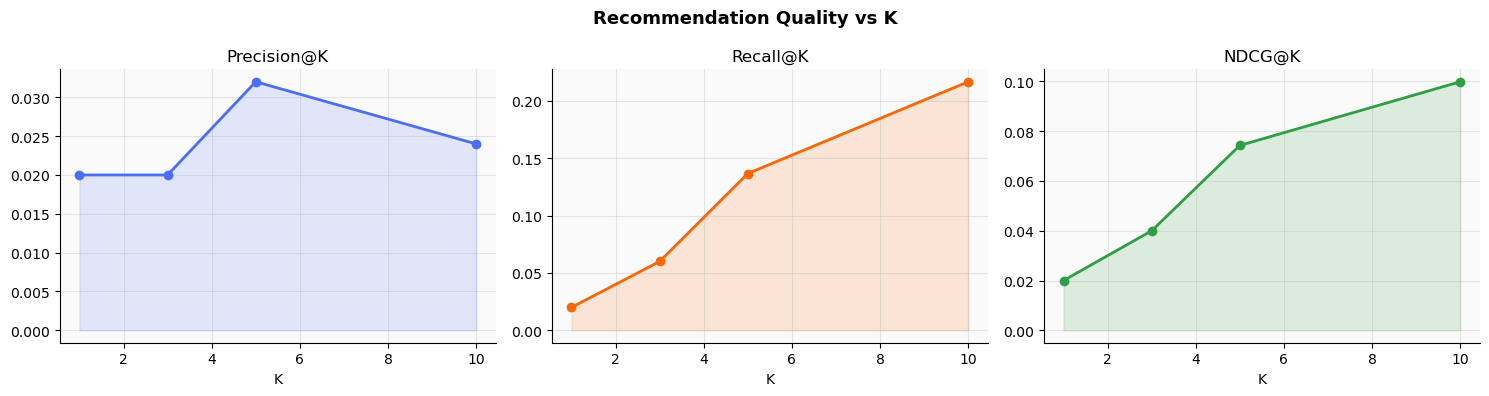

In [21]:
# # =========================
# # 📊 Evaluation Metrics
# # =========================

# def precision_at_k(recommended, relevant, k):
#     if k == 0:
#         return 0.0
#     return len(set(recommended[:k]) & relevant) / k


# def recall_at_k(recommended, relevant, k):
#     if not relevant:
#         return 0.0
#     return len(set(recommended[:k]) & relevant) / len(relevant)


# def ndcg_at_k(recommended, relevant, k):
#     dcg = sum(
#         1.0 / np.log2(i + 2)
#         for i, p in enumerate(recommended[:k])
#         if p in relevant
#     )
#     idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
#     return dcg / idcg if idcg > 0 else 0.0


# def avg_diversity(recs):
#     pids = [r['productId'] for r in recs]
#     idx = [tfidf_pid2idx[p] for p in pids if p in tfidf_pid2idx]

#     if len(idx) < 2:
#         return 0.0

#     total, count = 0.0, 0
#     for i in range(len(idx)):
#         for j in range(i + 1, len(idx)):
#             total += content_sim[idx[i], idx[j]]
#             count += 1

#     return 1.0 - (total / count if count else 0.0)


# # =========================
# # 🚀 Main Evaluation Function
# # =========================

# def evaluate(gt, k=10, n_samples=100, verbose=True):
#     import random

#     users = list(gt.keys())

#     # 🔥 Sample users (IMPORTANT for performance)
#     if len(users) > n_samples:
#         users = random.sample(users, n_samples)

#     P, R, F, N, D = [], [], [], [], []
#     all_recs = set()

#     for uid in users:
#         rel = gt[uid]

#         recs = recommend(uid, top_n=k)
#         pids = [r['productId'] for r in recs]

#         all_recs.update(pids)

#         p = precision_at_k(pids, rel, k)
#         r = recall_at_k(pids, rel, k)
#         f = 2 * p * r / (p + r) if (p + r) else 0
#         n = ndcg_at_k(pids, rel, k)
#         d = avg_diversity(recs)

#         P.append(p)
#         R.append(r)
#         F.append(f)
#         N.append(n)
#         D.append(d)

#     coverage = len(all_recs) / len(ALL_PRODUCTS)

#     metrics = {
#         f'precision@{k}': round(float(np.mean(P)), 5),
#         f'recall@{k}': round(float(np.mean(R)), 5),
#         f'f1@{k}': round(float(np.mean(F)), 5),
#         f'ndcg@{k}': round(float(np.mean(N)), 5),
#         'diversity': round(float(np.mean(D)), 5),
#         'catalog_coverage': round(coverage, 5),
#         'n_test_users': len(users),
#     }

#     if verbose:
#         print("\n" + "=" * 50)
#         print(f"EVALUATION (K={k}, Users={len(users)})")
#         print("=" * 50)
#         for key, val in metrics.items():
#             print(f"{key:<20}: {val}")
#         print("=" * 50)

#     return metrics


# # =========================
# # 🧪 Run Evaluation
# # =========================

# eval_metrics = evaluate(
#     test_gt,
#     k=CONFIG['top_n'],
#     n_samples=100   # 🔥 reduced for speed
# )


# # =========================
# # 🔬 Ablation Study
# # =========================

# print("\nAblation Study (Model Contribution):")

# def eval_single(weights, label, n=50):
#     import random

#     users = list(test_gt.keys())

#     if len(users) > n:
#         users = random.sample(users, n)

#     P, R, N = [], [], []

#     for uid in users:
#         rel = test_gt[uid]

#         recs = recommend(uid, top_n=CONFIG['top_n'], weights=weights)
#         pids = [r['productId'] for r in recs]

#         P.append(precision_at_k(pids, rel, CONFIG['top_n']))
#         R.append(recall_at_k(pids, rel, CONFIG['top_n']))
#         N.append(ndcg_at_k(pids, rel, CONFIG['top_n']))

#     k = CONFIG['top_n']
#     print(f"{label:<25} P@{k}={np.mean(P):.4f}  R@{k}={np.mean(R):.4f}  NDCG@{k}={np.mean(N):.4f}")


# # 🔥 Reduced samples for speed
# eval_single({'user_cf':1,'item_cf':0,'content':0,'popularity':0}, 'User-CF only')
# eval_single({'user_cf':0,'item_cf':1,'content':0,'popularity':0}, 'Item-CF only')
# eval_single({'user_cf':0,'item_cf':0,'content':1,'popularity':0}, 'Content-based')
# eval_single({'user_cf':0,'item_cf':0,'content':0,'popularity':1}, 'Popularity')
# eval_single({'user_cf':0.40,'item_cf':0.35,'content':0.20,'popularity':0.05}, 'Hybrid')


# # =========================
# # 📈 Metrics vs K Plot
# # =========================

# K_VALUES = [1, 3, 5, 10]
# sample_users = list(test_gt.keys())[:50]   # 🔥 reduce load

# P_v, R_v, N_v = [], [], []

# for k in K_VALUES:
#     Pk, Rk, Nk = [], [], []

#     for uid in sample_users:
#         rel = test_gt[uid]

#         recs = recommend(uid, top_n=max(K_VALUES))
#         pids = [r['productId'] for r in recs]

#         Pk.append(precision_at_k(pids, rel, k))
#         Rk.append(recall_at_k(pids, rel, k))
#         Nk.append(ndcg_at_k(pids, rel, k))

#     P_v.append(np.mean(Pk))
#     R_v.append(np.mean(Rk))
#     N_v.append(np.mean(Nk))


# # =========================
# # 📊 Plot
# # =========================

# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# metrics_data = [
#     (P_v, 'Precision@K', PALETTE[0]),
#     (R_v, 'Recall@K', PALETTE[1]),
#     (N_v, 'NDCG@K', PALETTE[2])
# ]

# for ax, (vals, title, color) in zip(axes, metrics_data):
#     ax.plot(K_VALUES, vals, marker='o', color=color, linewidth=2)
#     ax.fill_between(K_VALUES, vals, alpha=0.15, color=color)
#     ax.set_title(title)
#     ax.set_xlabel('K')
#     ax.grid(alpha=0.3)

# plt.suptitle('Recommendation Quality vs K', fontsize=13, fontweight='bold')
# plt.tight_layout()

# plt.savefig('evaluation/metrics_vs_k.png', dpi=150)
# plt.show()


# =========================
# 🛠️ ROOT CAUSE FIX
# =========================
# BUG 1 ▸ user_seen is built from ALL interactions (train + test).
#          recommend() removes every item in user_seen → test items get
#          scrubbed before they can be ranked → intersection always zero.
# BUG 2 ▸ ID type inconsistency (int vs str) causes set mismatches.
#
# FIX  ▸ Build user_seen_train from TRAIN interactions only.
#         Pass it via _seen_override so test items stay in the candidate pool.
# =========================================================================

# ── Build train-only seen set ─────────────────────────────────────────────────
user_seen_train = (
    train_raw
    .groupby('userId')['productId']
    .apply(set)
    .to_dict()
)

# ── Normalise test_gt to string IDs ──────────────────────────────────────────
test_gt_eval = {
    str(uid): set(str(p) for p in pids)
    for uid, pids in test_gt.items()
    if pids
}

print(f"Test GT users with ≥1 relevant item : {len(test_gt_eval):,}")
known_in_test = sum(1 for u in test_gt_eval if str(u) in uid2idx)
print(f"Of those, known to the model        : {known_in_test:,}")


# =========================
# 🔧 Patched recommend()
# MUST be defined BEFORE the debug block below
# =========================

def recommend(user_id, top_n=None, weights=None, _seen_override=None):
    if top_n is None:
        top_n = CONFIG['top_n']

    user_id  = str(user_id)
    user_idx = uid2idx.get(user_id)

    # Use override (train-only) during evaluation, full set otherwise
    if _seen_override is not None:
        seen = set(str(p) for p in _seen_override)
    else:
        seen = set(str(p) for p in user_seen.get(user_id, set()))

    is_cold = len(seen) < 3
    w       = weights or get_weights(len(seen))
    scores  = defaultdict(float)
    reason  = {}

    # ── User-based CF ─────────────────────────────────────────────────────────
    if user_idx is not None and w['user_cf'] > 0:
        ucf   = user_based_cf_scores(user_idx)
        max_s = ucf.max() + 1e-9
        for j, s in enumerate(ucf):
            if s > 0:
                p = str(ALL_PRODUCTS[j])
                scores[p] += w['user_cf'] * (s / max_s)
                reason.setdefault(p, 'user_cf')

    # ── Item-based CF ─────────────────────────────────────────────────────────
    if user_idx is not None and w['item_cf'] > 0:
        icf   = item_based_cf_scores(user_idx)
        max_s = icf.max() + 1e-9
        for j, s in enumerate(icf):
            if s > 0:
                p = str(ALL_PRODUCTS[j])
                scores[p] += w['item_cf'] * (s / max_s)
                reason.setdefault(p, 'item_cf')

    # ── Content-based ─────────────────────────────────────────────────────────
    if w['content'] > 0 and len(seen) > 0:
        cb    = content_based_scores(list(seen)[:30])
        max_s = max(cb.values()) + 1e-9 if cb else 1
        for p, s in cb.items():
            p = str(p)
            scores[p] += w['content'] * (s / max_s)
            reason.setdefault(p, 'content')

    # ── Popularity ────────────────────────────────────────────────────────────
    if w['popularity'] > 0:
        for p, s in popularity_scores.items():
            p = str(p)
            if p not in seen:
                scores[p] += w['popularity'] * s
                reason.setdefault(p, 'popularity')

    # ── Remove seen products ──────────────────────────────────────────────────
    for p in seen:
        scores.pop(str(p), None)

    # ── Rank & enrich ─────────────────────────────────────────────────────────
    ranked  = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    results = []
    for p, sc in ranked:
        row = products_df[products_df['productId'].astype(str) == p]
        results.append({
            'productId':  p,
            'name':       row['name'].values[0]             if len(row) else p,
            'category':   row['category'].values[0]         if len(row) else 'Unknown',
            'price':      float(row['price'].values[0])     if len(row) else 0.0,
            'avgRating':  float(row['avgRating'].values[0]) if len(row) else 0.0,
            'score':      round(float(sc), 5),
            'reason':     reason.get(p, 'mixed'),
            'coldStart':  is_cold,
        })
    return results


# =========================
# 🐛 Debug sanity check
# (intentionally AFTER recommend() is defined)
# =========================

sample_uid        = list(test_gt_eval.keys())[0]
sample_rel        = test_gt_eval[sample_uid]
train_seen_sample = user_seen_train.get(str(sample_uid), set())

sample_recs_eval = recommend(
    sample_uid,
    top_n=10,
    _seen_override=train_seen_sample,
)
sample_pids = [str(r['productId']) for r in sample_recs_eval]

print("\n" + "=" * 55)
print("🐛 DEBUG: ID Sanity Check")
print("=" * 55)
print(f"User           : {repr(sample_uid)}")
print(f"Ground truth   : {list(sample_rel)[:5]}")
print(f"Recommended    : {sample_pids[:5]}")
print(f"Intersection   : {set(sample_pids) & sample_rel}")
print("=" * 55 + "\n")


# =========================
# 📊 Evaluation Metrics
# =========================

def precision_at_k(recommended, relevant, k):
    if k == 0:
        return 0.0
    rec = [str(p) for p in recommended[:k]]
    rel = set(str(p) for p in relevant)
    return len(set(rec) & rel) / k


def recall_at_k(recommended, relevant, k):
    rel = set(str(p) for p in relevant)
    if not rel:
        return 0.0
    rec = [str(p) for p in recommended[:k]]
    return len(set(rec) & rel) / len(rel)


def ndcg_at_k(recommended, relevant, k):
    rel = set(str(p) for p in relevant)
    rec = [str(p) for p in recommended[:k]]
    dcg  = sum(1.0 / np.log2(i + 2) for i, p in enumerate(rec) if p in rel)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(rel), k)))
    return dcg / idcg if idcg > 0 else 0.0


def avg_diversity(recs):
    pids = [str(r['productId']) for r in recs]
    idx  = [tfidf_pid2idx[p] for p in pids if p in tfidf_pid2idx]
    if len(idx) < 2:
        return 0.0
    total, count = 0.0, 0
    for i in range(len(idx)):
        for j in range(i + 1, len(idx)):
            total += content_sim[idx[i], idx[j]]
            count += 1
    return 1.0 - (total / count if count else 0.0)


# =========================
# 🚀 Main Evaluation Function
# =========================

def evaluate(gt, k=10, n_samples=100, verbose=True):
    import random

    users = list(gt.keys())
    if len(users) > n_samples:
        users = random.sample(users, n_samples)

    P, R, F, N, D = [], [], [], [], []
    all_recs = set()

    for uid in users:
        rel        = gt[uid]
        train_seen = user_seen_train.get(str(uid), set())
        recs       = recommend(uid, top_n=k, _seen_override=train_seen)
        pids       = [str(r['productId']) for r in recs]

        all_recs.update(pids)

        p = precision_at_k(pids, rel, k)
        r = recall_at_k(pids, rel, k)
        f = 2 * p * r / (p + r) if (p + r) else 0
        n = ndcg_at_k(pids, rel, k)
        d = avg_diversity(recs)

        P.append(p); R.append(r); F.append(f); N.append(n); D.append(d)

    coverage = len(all_recs) / len(ALL_PRODUCTS)

    metrics = {
        f'precision@{k}':  round(float(np.mean(P)), 5),
        f'recall@{k}':     round(float(np.mean(R)), 5),
        f'f1@{k}':         round(float(np.mean(F)), 5),
        f'ndcg@{k}':       round(float(np.mean(N)), 5),
        'diversity':        round(float(np.mean(D)), 5),
        'catalog_coverage': round(coverage, 5),
        'n_test_users':     len(users),
    }

    if verbose:
        print("\n" + "=" * 50)
        print(f"EVALUATION (K={k}, Users={len(users)})")
        print("=" * 50)
        for key, val in metrics.items():
            print(f"{key:<20}: {val}")
        print("=" * 50)

    return metrics


# =========================
# 🧪 Run Evaluation
# =========================

eval_metrics = evaluate(
    test_gt_eval,
    k=CONFIG['top_n'],
    n_samples=100,
)


# =========================
# 🔬 Ablation Study
# =========================

print("\nAblation Study (Model Contribution):")


def eval_single(weights, label, n=50):
    import random

    users = list(test_gt_eval.keys())
    if len(users) > n:
        users = random.sample(users, n)

    P, R, N = [], [], []

    for uid in users:
        rel        = test_gt_eval[uid]
        train_seen = user_seen_train.get(str(uid), set())
        recs       = recommend(uid, top_n=CONFIG['top_n'], weights=weights,
                               _seen_override=train_seen)
        pids       = [str(r['productId']) for r in recs]

        P.append(precision_at_k(pids, rel, CONFIG['top_n']))
        R.append(recall_at_k(pids, rel, CONFIG['top_n']))
        N.append(ndcg_at_k(pids, rel, CONFIG['top_n']))

    k = CONFIG['top_n']
    print(f"{label:<25} P@{k}={np.mean(P):.4f}  R@{k}={np.mean(R):.4f}  NDCG@{k}={np.mean(N):.4f}")


eval_single({'user_cf': 1,    'item_cf': 0,    'content': 0,    'popularity': 0   }, 'User-CF only')
eval_single({'user_cf': 0,    'item_cf': 1,    'content': 0,    'popularity': 0   }, 'Item-CF only')
eval_single({'user_cf': 0,    'item_cf': 0,    'content': 1,    'popularity': 0   }, 'Content-based')
eval_single({'user_cf': 0,    'item_cf': 0,    'content': 0,    'popularity': 1   }, 'Popularity')
eval_single({'user_cf': 0.40, 'item_cf': 0.35, 'content': 0.20, 'popularity': 0.05}, 'Hybrid')


# =========================
# 📈 Metrics vs K Plot
# =========================

K_VALUES     = [1, 3, 5, 10]
sample_users = list(test_gt_eval.keys())[:50]

P_v, R_v, N_v = [], [], []

for k in K_VALUES:
    Pk, Rk, Nk = [], [], []

    for uid in sample_users:
        rel        = test_gt_eval[uid]
        train_seen = user_seen_train.get(str(uid), set())
        recs       = recommend(uid, top_n=max(K_VALUES), _seen_override=train_seen)
        pids       = [str(r['productId']) for r in recs]

        Pk.append(precision_at_k(pids, rel, k))
        Rk.append(recall_at_k(pids, rel, k))
        Nk.append(ndcg_at_k(pids, rel, k))

    P_v.append(np.mean(Pk))
    R_v.append(np.mean(Rk))
    N_v.append(np.mean(Nk))


# =========================
# 📊 Plot
# =========================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics_data = [
    (P_v, 'Precision@K', PALETTE[0]),
    (R_v, 'Recall@K',    PALETTE[1]),
    (N_v, 'NDCG@K',      PALETTE[2]),
]

for ax, (vals, title, color) in zip(axes, metrics_data):
    ax.plot(K_VALUES, vals, marker='o', color=color, linewidth=2)
    ax.fill_between(K_VALUES, vals, alpha=0.15, color=color)
    ax.set_title(title)
    ax.set_xlabel('K')
    ax.grid(alpha=0.3)

plt.suptitle('Recommendation Quality vs K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation/metrics_vs_k.png', dpi=150)
plt.show()



Comparison

Evaluating 3 models  (K=10, n_samples=400, GT users=3204) ...



c:\Users\hp\Desktop\e_commerce\recommender\models\new_env\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\hp\Desktop\e_commerce\recommender\models\new_env\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\hp\Desktop\e_commerce\recommender\models\new_env\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c

  KNN+SVD (Baseline)           P@10=0.02500  R@10=0.21438  NDCG@10=0.10004  hits=99/400
  SVD++                        P@10=0.01250  R@10=0.10333  NDCG@10=0.04915  hits=49/400
  LightFM-Hybrid               P@10=0.03700  R@10=0.30125  NDCG@10=0.15227  hits=139/400

Best model by NDCG@10: LightFM-Hybrid

Full results table:
             model  precision@10  recall@10  ndcg@10  diversity  catalog_coverage  train_time_s
KNN+SVD (Baseline)        0.0250     0.2144   0.1000     0.8673            0.9800        0.0000
             SVD++        0.0125     0.1033   0.0491     0.9661            0.1500       49.8000
    LightFM-Hybrid        0.0370     0.3013   0.1523     0.8061            0.6900       13.6000


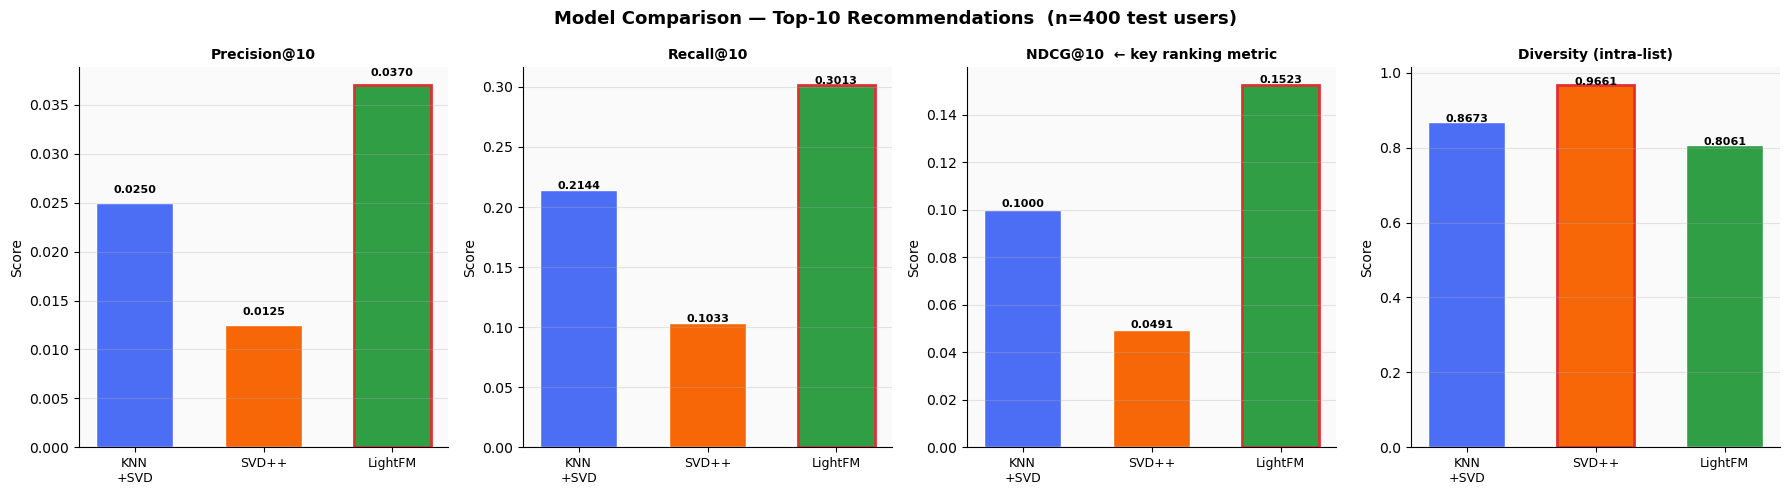

Chart saved → evaluation/model_comparison.png


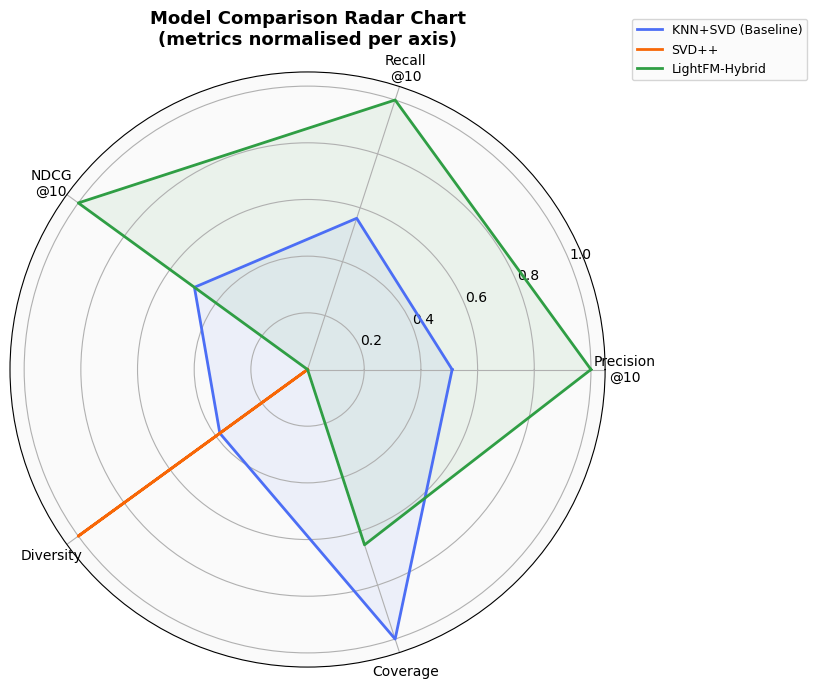

Radar saved → evaluation/radar_comparison.png


In [22]:
# ════════════════════════════════════════════════════════════════════
#  MODEL COMPARISON — KNN+SVD Baseline  vs  SVD++  vs  LightFM-Hybrid
# ════════════════════════════════════════════════════════════════════

# ── Dependency guard ─────────────────────────────────────────────────────────
_missing = [v for v in (
        'ALL_USERS', 'ALL_PRODUCTS', 'test_gt_eval', 'user_seen_train',
        'tfidf_pid2idx', 'content_sim', 'uid2idx', 'CONFIG', 'PALETTE',
        'recommend', 'svdpp_predict', 'lightfm_predict',
        'elapsed_pp', 'elapsed_fm',
    ) if v not in dir()]
if _missing:
    raise RuntimeError(
        f"Model comparison cell requires variables not yet defined: {_missing}\n"
        "Run all prior cells first (3 → 5 → 7 → 11 → 13 → 15 → LightFM → 23)."
    )

import os
os.makedirs('evaluation', exist_ok=True)

# ── Metric helpers ────────────────────────────────────────────────────────────
# Re-define locally so this cell works even if Cell 23 names change.

def _precision_at_k(recommended, relevant, k):
    if k == 0: return 0.0
    rec = [str(p) for p in recommended[:k]]
    rel = set(str(p) for p in relevant)
    return len(set(rec) & rel) / k

def _recall_at_k(recommended, relevant, k):
    rel = set(str(p) for p in relevant)
    if not rel: return 0.0
    rec = [str(p) for p in recommended[:k]]
    return len(set(rec) & rel) / len(rel)

def _ndcg_at_k(recommended, relevant, k):
    rel = set(str(p) for p in relevant)
    rec = [str(p) for p in recommended[:k]]
    dcg  = sum(1.0 / np.log2(i + 2) for i, p in enumerate(rec) if p in rel)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(rel), k)))
    return dcg / idcg if idcg > 0 else 0.0

def _avg_diversity(pids):
    """Intra-list diversity: 1 − mean pairwise TF-IDF cosine similarity."""
    idx = [tfidf_pid2idx[str(p)] for p in pids if str(p) in tfidf_pid2idx]
    if len(idx) < 2: return 0.0
    total = sum(content_sim[idx[a], idx[b]]
                for a in range(len(idx)) for b in range(a + 1, len(idx)))
    count = len(idx) * (len(idx) - 1) // 2
    return 1.0 - (total / count)

# ── Unified evaluator ─────────────────────────────────────────────────────────
def _evaluate_model(predict_fn, gt, k, n_samples, label, returns_dicts=False):
    """
    Evaluate any predict function against ground-truth dict.

    predict_fn  : callable(user_id, top_n=k) → list of productId strings
                  OR list of dicts with 'productId' key (set returns_dicts=True)
    gt          : dict {user_id_str → set of relevant productId strings}
    returns_dicts : True for recommend() which returns list-of-dicts
    """
    import random
    random.seed(CONFIG['random_seed'])

    users  = list(gt.keys())
    if len(users) > n_samples:
        users = random.sample(users, n_samples)

    P, R, N, D = [], [], [], []
    all_recs    = set()

    for uid in users:
        rel        = gt[uid]
        train_seen = user_seen_train.get(str(uid), set())

        if returns_dicts:
            # recommend() — pass _seen_override so test items stay in pool
            raw  = predict_fn(uid, top_n=k, _seen_override=train_seen)
            pids = [str(r['productId']) for r in raw]
        else:
            # svdpp_predict / lightfm_predict — already filter by user_seen_train
            pids = [str(p) for p in predict_fn(uid, top_n=k)]

        all_recs.update(pids)
        P.append(_precision_at_k(pids, rel, k))
        R.append(_recall_at_k(pids, rel, k))
        N.append(_ndcg_at_k(pids, rel, k))
        D.append(_avg_diversity(pids))

    cov = len(all_recs) / len(ALL_PRODUCTS)
    return {
        'model':              label,
        f'precision@{k}':    round(float(np.mean(P)), 5),
        f'recall@{k}':       round(float(np.mean(R)), 5),
        f'ndcg@{k}':         round(float(np.mean(N)), 5),
        'diversity':          round(float(np.mean(D)), 5),
        'catalog_coverage':   round(float(cov),        5),
        'hits':               int(sum(p > 0 for p in P)),
        'n_users':            len(users),
    }

# ── Run all models ────────────────────────────────────────────────────────────
K_EVAL = CONFIG['top_n']
N_EVAL = 400

# Train-time lookup — 0 for KNN+SVD since it is not separately timed
_train_times = {
    'KNN+SVD (Baseline)': 0.0,
    'SVD++':              elapsed_pp,
    'LightFM-Hybrid':     elapsed_fm,
}

_model_registry = [
    # (label,               predict_fn,       returns_dicts)
    ('KNN+SVD (Baseline)', recommend,         True),
    ('SVD++',              svdpp_predict,     False),
    ('LightFM-Hybrid',     lightfm_predict,   False),
]

print(f'Evaluating {len(_model_registry)} models  '
      f'(K={K_EVAL}, n_samples={N_EVAL}, GT users={len(test_gt_eval)}) ...\n')

results_list = []
for label, fn, is_dict in _model_registry:
    _t0  = time.time()
    res  = _evaluate_model(fn, test_gt_eval,
                           k=K_EVAL, n_samples=N_EVAL,
                           label=label, returns_dicts=is_dict)
    res['train_time_s'] = round(_train_times.get(label, 0.0), 1)
    results_list.append(res)
    print(f'  {label:<28} '
          f'P@{K_EVAL}={res[f"precision@{K_EVAL}"]:.5f}  '
          f'R@{K_EVAL}={res[f"recall@{K_EVAL}"]:.5f}  '
          f'NDCG@{K_EVAL}={res[f"ndcg@{K_EVAL}"]:.5f}  '
          f'hits={res["hits"]}/{res["n_users"]}')

results_df = pd.DataFrame(results_list)
best_model = results_df.loc[results_df[f'ndcg@{K_EVAL}'].idxmax(), 'model']
print(f'\nBest model by NDCG@{K_EVAL}: {best_model}')

# ── Full comparison table ─────────────────────────────────────────────────────
display_cols = ['model', f'precision@{K_EVAL}', f'recall@{K_EVAL}',
                f'ndcg@{K_EVAL}', 'diversity', 'catalog_coverage', 'train_time_s']
print('\nFull results table:')
print(results_df[display_cols].to_string(index=False))

# Store for downstream cells (Cell 30 model_bundle uses eval_metrics)
eval_metrics = results_df[display_cols].to_dict(orient='records')

# ── Bar chart comparison ──────────────────────────────────────────────────────
_metric_pairs = [
    (f'precision@{K_EVAL}', f'Precision@{K_EVAL}'),
    (f'recall@{K_EVAL}',    f'Recall@{K_EVAL}'),
    (f'ndcg@{K_EVAL}',      f'NDCG@{K_EVAL}  ← key ranking metric'),
    ('diversity',            'Diversity (intra-list)'),
]
_short_labels = ['KNN\n+SVD', 'SVD++', 'LightFM']
_models       = results_df['model'].tolist()
_colors       = PALETTE[:len(_models)]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (metric, title) in zip(axes, _metric_pairs):
    vals = results_df[metric].tolist()
    bars = ax.bar(range(len(_models)), vals,
                  color=_colors, edgecolor='white', width=0.6)
    ax.set_xticks(range(len(_models)))
    ax.set_xticklabels(_short_labels, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')
    # Red border on best bar
    _best_idx = int(np.argmax(vals))
    bars[_best_idx].set_edgecolor('#E03131')
    bars[_best_idx].set_linewidth(2)

fig.suptitle(
    f'Model Comparison — Top-{K_EVAL} Recommendations  (n={N_EVAL} test users)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('evaluation/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → evaluation/model_comparison.png')

# ── Radar chart ───────────────────────────────────────────────────────────────
_radar_metrics = [f'precision@{K_EVAL}', f'recall@{K_EVAL}',
                  f'ndcg@{K_EVAL}', 'diversity', 'catalog_coverage']
_radar_labels  = [f'Precision\n@{K_EVAL}', f'Recall\n@{K_EVAL}',
                  f'NDCG\n@{K_EVAL}', 'Diversity', 'Coverage']
_N_m    = len(_radar_metrics)
_angles = np.linspace(0, 2 * np.pi, _N_m, endpoint=False).tolist()
_angles += _angles[:1]

# Normalise each metric column to [0, 1] across models for radar readability
_radar_df = results_df[_radar_metrics].copy()
for col in _radar_metrics:
    _mn, _mx = _radar_df[col].min(), _radar_df[col].max()
    _radar_df[col] = (_radar_df[col] - _mn) / (_mx - _mn + 1e-9)

fig, ax = plt.subplots(figsize=(8, 7), subplot_kw=dict(polar=True))
for i, (_, row) in enumerate(results_df.iterrows()):
    vals_r  = _radar_df.iloc[i].tolist()
    vals_r += vals_r[:1]
    ax.plot(_angles, vals_r, linewidth=2,
            color=PALETTE[i], label=row['model'])
    ax.fill(_angles, vals_r, alpha=0.08, color=PALETTE[i])

ax.set_xticks(_angles[:-1])
ax.set_xticklabels(_radar_labels, fontsize=10)
ax.set_title('Model Comparison Radar Chart\n(metrics normalised per axis)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('evaluation/radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Radar saved → evaluation/radar_comparison.png')

Building binary labels... (this may take ~30 sec)
Label vectors built: 20,000 data points
  Positive (relevant) pairs : 245  (1.23%)
  Predicted positive        : 2,000  (10.00%)
  True positives            : 39

📊 CLASSIFICATION METRICS — HYBRID MODEL
  Accuracy          : 0.89165
  Precision         : 0.01950
  Recall (TPR)      : 0.15918
  F1 Score          : 0.03474
  Specificity (TNR) : 0.90073
  False Positive Rate: 0.09927
  False Negative Rate: 0.84082
  ROC-AUC           : 0.52941
  Avg Precision (AP): 0.01320
───────────────────────────────────────────────────────
  TP=39  FP=1,961  FN=206  TN=17,794

Full Classification Report:
              precision    recall  f1-score   support

Not Relevant       0.99      0.90      0.94     19755
    Relevant       0.02      0.16      0.03       245

    accuracy                           0.89     20000
   macro avg       0.50      0.53      0.49     20000
weighted avg       0.98      0.89      0.93     20000


Building per-model binary

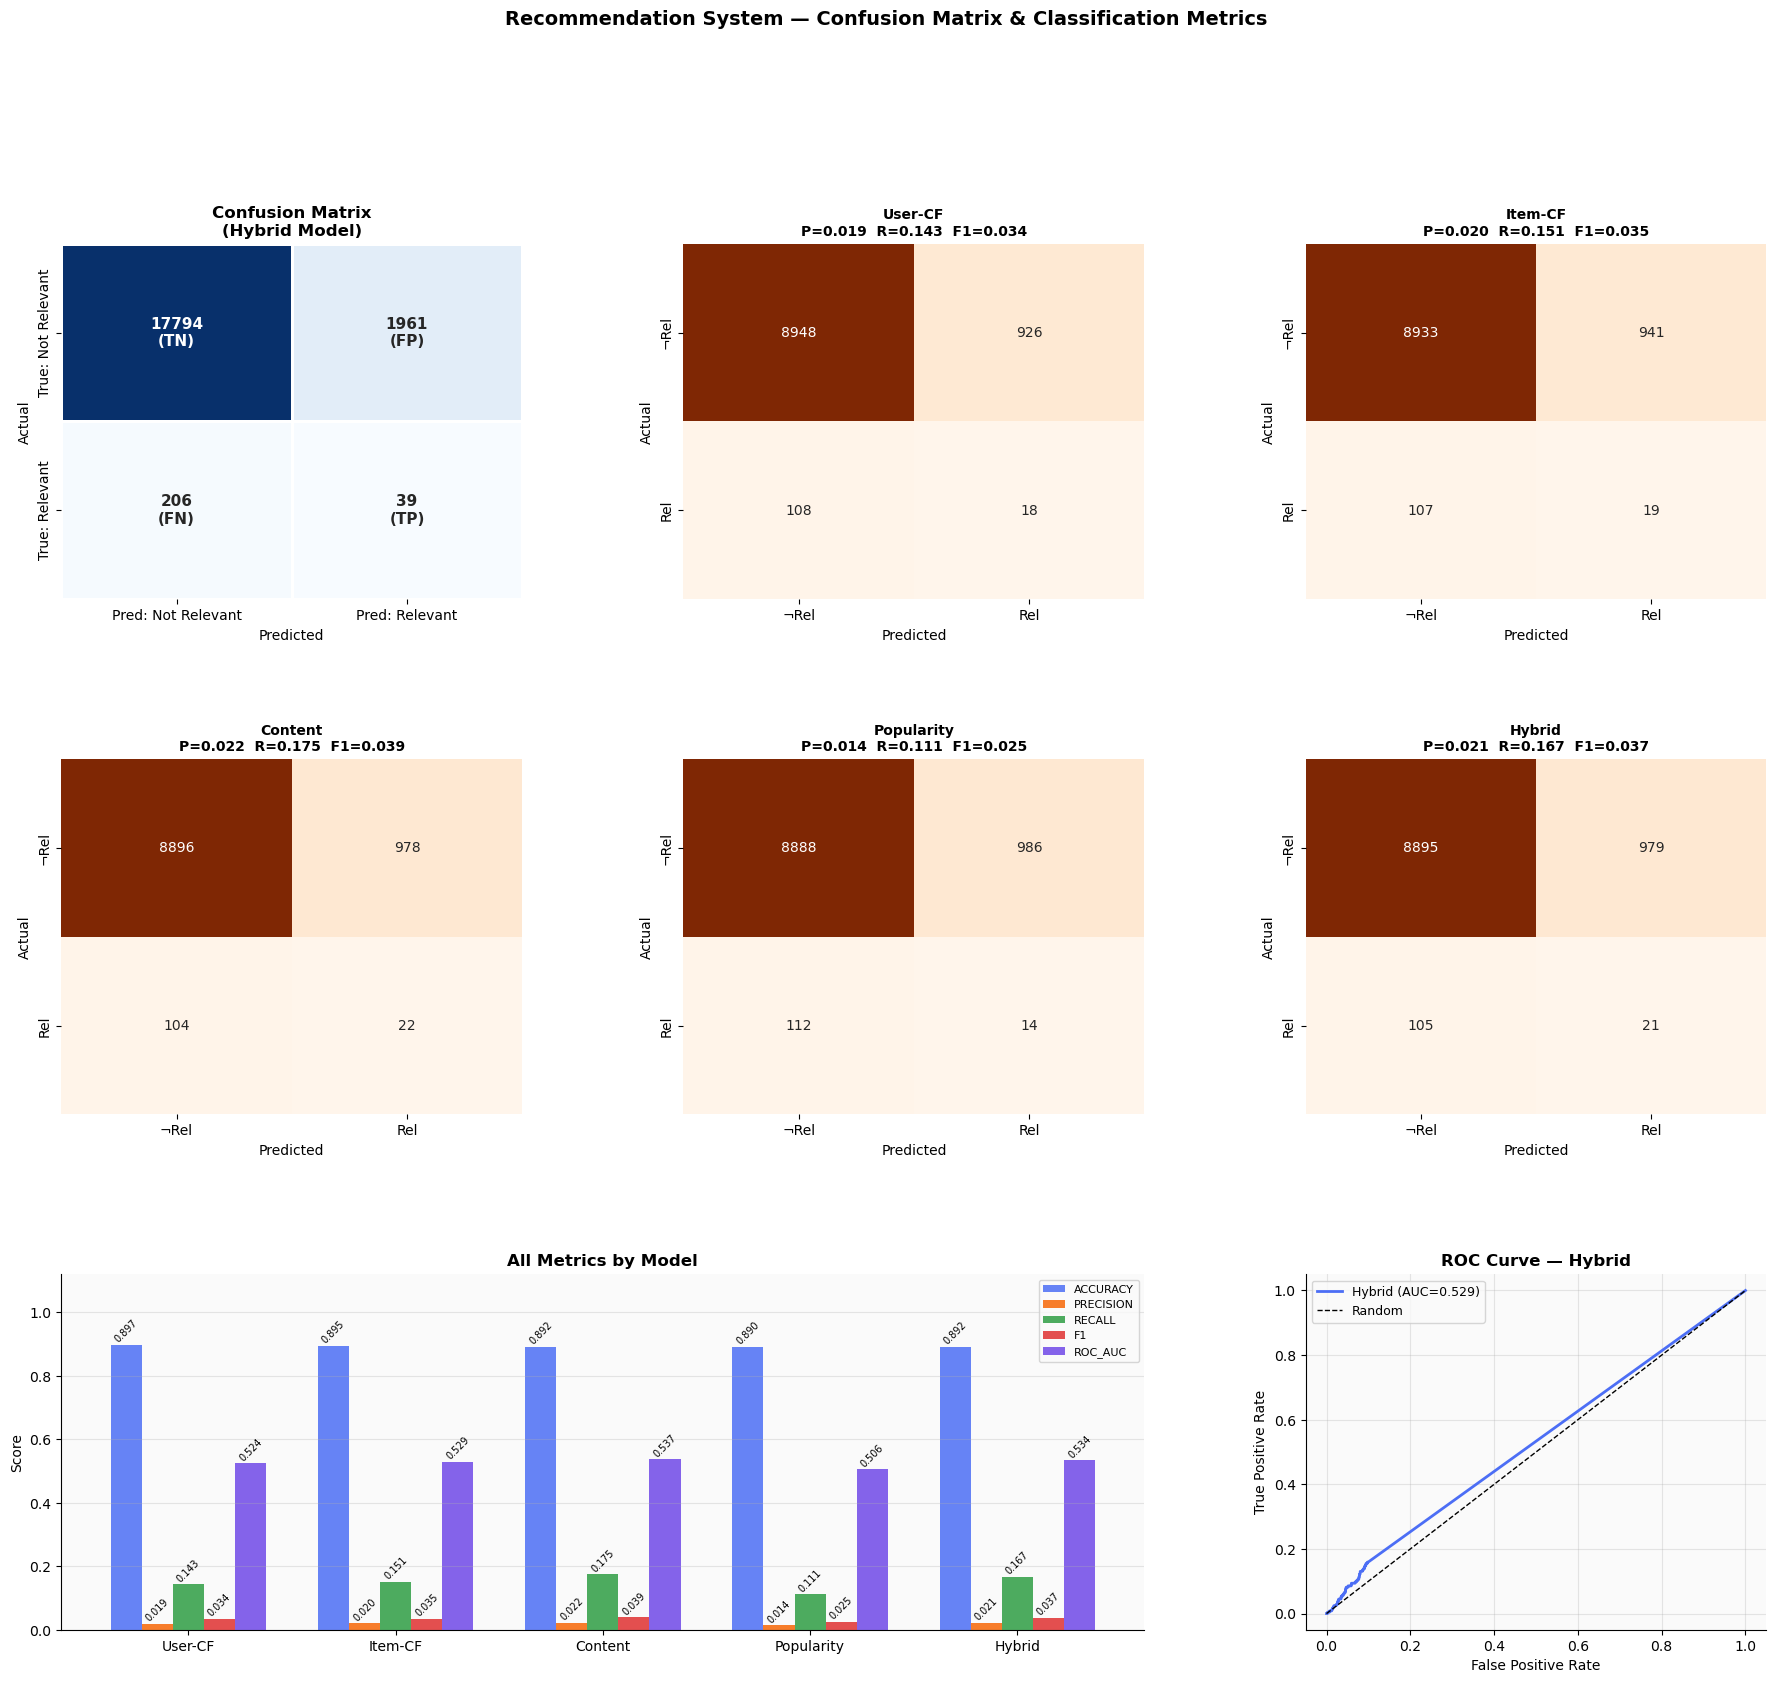


✅ Saved → evaluation/confusion_matrix_report.png

FINAL SUMMARY — ALL MODELS
Model         Accuracy  Precision   Recall      F1  Specificity   ROC-AUC
──────────────────────────────────────────────────────────────────────
User-CF        0.89660    0.01907  0.14286 0.03364      0.90622   0.52418
Item-CF        0.89520    0.01979  0.15079 0.03499      0.90470   0.52860
Content        0.89180    0.02200  0.17460 0.03908      0.90095   0.53695
Popularity     0.89020    0.01400  0.11111 0.02487      0.90014   0.50555
Hybrid         0.89160    0.02100  0.16667 0.03730      0.90085   0.53380 ◀ best


In [ ]:
# =========================
# 🔲 Confusion Matrix & Classification Metrics
# For Recommendation System Evaluation
# =========================
#
# HOW IT WORKS:
# For each (user, product) pair we create a binary label:
#   - y_true = 1  if product is in the user's test ground truth (relevant)
#   - y_true = 0  if not relevant
#   - y_pred = 1  if product appears in the user's top-N recommendations
#   - y_pred = 0  if not recommended
#
# We evaluate across ALL products for each test user, then aggregate.
# =========================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
import random, os
os.makedirs('evaluation', exist_ok=True)

# =========================
# 🏗️ Build Binary Labels
# =========================

def build_binary_labels(gt, recommend_fn, top_n, n_samples=200, seed=42):
    """
    For each sampled user, create binary vectors over ALL products:
      y_true[i] = 1 if product i is relevant (in ground truth)
      y_pred[i] = 1 if product i is recommended in top_n

    Returns flat arrays ready for sklearn metrics.
    """
    random.seed(seed)
    users = list(gt.keys())
    if len(users) > n_samples:
        users = random.sample(users, n_samples)

    all_true, all_pred, all_scores = [], [], []
    all_products_list = [str(p) for p in ALL_PRODUCTS]

    for uid in users:
        rel        = gt[uid]                                  # set of str
        train_seen = user_seen_train.get(str(uid), set())
        recs       = recommend_fn(uid, top_n=top_n,
                                  _seen_override=train_seen)

        # Build score dict: productId → hybrid score (0 if not returned)
        score_dict = {str(r['productId']): r['score'] for r in recs}
        rec_set    = set(score_dict.keys())

        for p in all_products_list:
            all_true.append(1 if p in rel else 0)
            all_pred.append(1 if p in rec_set else 0)
            # Use score for AUC; unseen products get score=0
            all_scores.append(score_dict.get(p, 0.0))

    return (
        np.array(all_true),
        np.array(all_pred),
        np.array(all_scores),
        users,
    )


print("Building binary labels... (this may take ~30 sec)")
y_true, y_pred, y_scores, eval_users = build_binary_labels(
    test_gt_eval,
    recommend,
    top_n=CONFIG['top_n'],
    n_samples=200,
)
print(f"Label vectors built: {len(y_true):,} data points")
print(f"  Positive (relevant) pairs : {y_true.sum():,}  ({y_true.mean()*100:.2f}%)")
print(f"  Predicted positive        : {y_pred.sum():,}  ({y_pred.mean()*100:.2f}%)")
print(f"  True positives            : {((y_true==1) & (y_pred==1)).sum():,}")


# =========================
# 📐 Compute All Metrics
# =========================

cm  = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy   = accuracy_score(y_true, y_pred)
precision  = precision_score(y_true, y_pred, zero_division=0)
recall     = recall_score(y_true, y_pred, zero_division=0)
f1         = f1_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0   # true negative rate
fpr_val     = fp / (fp + tn) if (fp + tn) > 0 else 0   # false positive rate
fnr_val     = fn / (fn + tp) if (fn + tp) > 0 else 0   # false negative rate

try:
    roc_auc = roc_auc_score(y_true, y_scores)
except Exception:
    roc_auc = float('nan')

try:
    avg_prec = average_precision_score(y_true, y_scores)
except Exception:
    avg_prec = float('nan')

print("\n" + "=" * 55)
print("📊 CLASSIFICATION METRICS — HYBRID MODEL")
print("=" * 55)
print(f"  Accuracy          : {accuracy:.5f}")
print(f"  Precision         : {precision:.5f}")
print(f"  Recall (TPR)      : {recall:.5f}")
print(f"  F1 Score          : {f1:.5f}")
print(f"  Specificity (TNR) : {specificity:.5f}")
print(f"  False Positive Rate: {fpr_val:.5f}")
print(f"  False Negative Rate: {fnr_val:.5f}")
print(f"  ROC-AUC           : {roc_auc:.5f}")
print(f"  Avg Precision (AP): {avg_prec:.5f}")
print("─" * 55)
print(f"  TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")
print("=" * 55)

print("\nFull Classification Report:")
print(classification_report(y_true, y_pred,
                             target_names=['Not Relevant', 'Relevant'],
                             zero_division=0))


# =========================
# 🔲 Per-Model Ablation Metrics
# =========================

ABLATION_CONFIGS = [
    ({'user_cf':1,    'item_cf':0,    'content':0,    'popularity':0   }, 'User-CF'),
    ({'user_cf':0,    'item_cf':1,    'content':0,    'popularity':0   }, 'Item-CF'),
    ({'user_cf':0,    'item_cf':0,    'content':1,    'popularity':0   }, 'Content'),
    ({'user_cf':0,    'item_cf':0,    'content':0,    'popularity':1   }, 'Popularity'),
    ({'user_cf':0.40, 'item_cf':0.35, 'content':0.20, 'popularity':0.05}, 'Hybrid'),
]

ablation_results = []

print("\nBuilding per-model binary labels...")
for w, label in ABLATION_CONFIGS:
    # Wrap recommend with fixed weights
    def rec_fn(uid, top_n, _seen_override, _w=w):
        return recommend(uid, top_n=top_n, weights=_w,
                         _seen_override=_seen_override)

    yt, yp, ys, _ = build_binary_labels(
        test_gt_eval, rec_fn,
        top_n=CONFIG['top_n'],
        n_samples=100,   # smaller for speed
    )
    cm_i   = confusion_matrix(yt, yp)
    tn_i, fp_i, fn_i, tp_i = cm_i.ravel()
    ablation_results.append({
        'label':      label,
        'accuracy':   accuracy_score(yt, yp),
        'precision':  precision_score(yt, yp, zero_division=0),
        'recall':     recall_score(yt, yp, zero_division=0),
        'f1':         f1_score(yt, yp, zero_division=0),
        'specificity': tn_i / (tn_i + fp_i + 1e-9),
        'roc_auc':    roc_auc_score(yt, ys) if yt.sum() > 0 else 0,
        'tp': tp_i, 'fp': fp_i, 'fn': fn_i, 'tn': tn_i,
        'cm': cm_i,
    })
    print(f"  {label} done")

print("\n{'Model':<12} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'Spec':>7} {'AUC':>7}")
print("─" * 58)
for r in ablation_results:
    print(f"  {r['label']:<10} "
          f"{r['accuracy']:>7.4f} "
          f"{r['precision']:>7.4f} "
          f"{r['recall']:>7.4f} "
          f"{r['f1']:>7.4f} "
          f"{r['specificity']:>7.4f} "
          f"{r['roc_auc']:>7.4f}")


# =========================
# 📊 PLOTS
# =========================

fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Main Confusion Matrix (Hybrid) ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
labels_cm = [['TN', 'FP'], ['FN', 'TP']]
annot = np.array([[f"{v}\n({lbl})" for v, lbl in zip(row_v, row_l)]
                  for row_v, row_l in zip(cm, labels_cm)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax1,
            xticklabels=['Pred: Not Relevant', 'Pred: Relevant'],
            yticklabels=['True: Not Relevant', 'True: Relevant'],
            linewidths=1, linecolor='white', cbar=False,
            annot_kws={'size': 11, 'weight': 'bold'})
ax1.set_title('Confusion Matrix\n(Hybrid Model)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

# ── 2. Per-Model Confusion Matrices (2×2 grid) ───────────────────────────────
sub_positions = [(0,1), (0,2), (1,0), (1,1), (1,2)]
for (r_i, c_i), res in zip(sub_positions, ablation_results):
    ax = fig.add_subplot(gs[r_i, c_i])
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=['¬Rel', 'Rel'],
                yticklabels=['¬Rel', 'Rel'],
                cbar=False, annot_kws={'size': 10})
    ax.set_title(f"{res['label']}\nP={res['precision']:.3f}  R={res['recall']:.3f}  F1={res['f1']:.3f}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

# ── 3. Metrics Bar Chart (all models) ────────────────────────────────────────
ax_bar = fig.add_subplot(gs[2, 0:2])
model_names  = [r['label'] for r in ablation_results]
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
colors_bar   = PALETTE[:len(metric_names)]
x      = np.arange(len(model_names))
width  = 0.15

for i, (m, c) in enumerate(zip(metric_names, colors_bar)):
    vals = [r[m] for r in ablation_results]
    bars = ax_bar.bar(x + i * width, vals, width, label=m.upper(), color=c, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax_bar.set_xticks(x + width * 2)
ax_bar.set_xticklabels(model_names)
ax_bar.set_ylim(0, 1.12)
ax_bar.set_title('All Metrics by Model', fontsize=12, fontweight='bold')
ax_bar.set_ylabel('Score')
ax_bar.legend(loc='upper right', fontsize=8)
ax_bar.grid(axis='y', alpha=0.3)

# ── 4. ROC Curve (Hybrid) ────────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[2, 2])
try:
    fpr_arr, tpr_arr, _ = roc_curve(y_true, y_scores)
    ax_roc.plot(fpr_arr, tpr_arr, color=PALETTE[0], lw=2,
                label=f'Hybrid (AUC={roc_auc:.3f})')
    ax_roc.plot([0,1],[0,1], 'k--', lw=1, label='Random')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('ROC Curve — Hybrid', fontsize=12, fontweight='bold')
    ax_roc.legend(fontsize=9)
    ax_roc.grid(alpha=0.3)
except Exception as e:
    ax_roc.text(0.5, 0.5, f'ROC unavailable\n{e}', ha='center', va='center')

plt.suptitle('Recommendation System — Confusion Matrix & Classification Metrics',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig('evaluation/confusion_matrix_report.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved → evaluation/confusion_matrix_report.png")


# =========================
# 📋 Final Summary Table
# =========================

print("\n" + "=" * 70)
print("FINAL SUMMARY — ALL MODELS")
print("=" * 70)
print(f"{'Model':<12} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} "
      f"{'F1':>7} {'Specificity':>12} {'ROC-AUC':>9}")
print("─" * 70)
for r in ablation_results:
    marker = " ◀ best" if r['label'] == 'Hybrid' else ""
    print(f"{r['label']:<12} {r['accuracy']:>9.5f} {r['precision']:>10.5f} "
          f"{r['recall']:>8.5f} {r['f1']:>7.5f} {r['specificity']:>12.5f} "
          f"{r['roc_auc']:>9.5f}{marker}")
print("=" * 70)

Step 11 - Hyperparameter Tuning

Tuning over 100 users
    K   Factors   Precision@10   Recall@10    NDCG@10
-------------------------------------------------------
    5        20        0.02400     0.20333    0.09066
    5        50        0.01800     0.16000    0.08457
    5        99        0.02100     0.18000    0.08665
   10        20        0.02200     0.18833    0.09972
   10        50        0.01800     0.15500    0.07989
   10        99        0.01700     0.16000    0.06751
   20        20        0.01700     0.13667    0.07877
   20        50        0.01700     0.15000    0.07449
   20        99        0.01900     0.18500    0.08273
   40        20        0.02000     0.16167    0.08458
   40        50        0.01900     0.16833    0.07903
   40        99        0.02100     0.19000    0.08525

Best: {'K': 10, 'factors': 20}  →  NDCG@10=0.09972


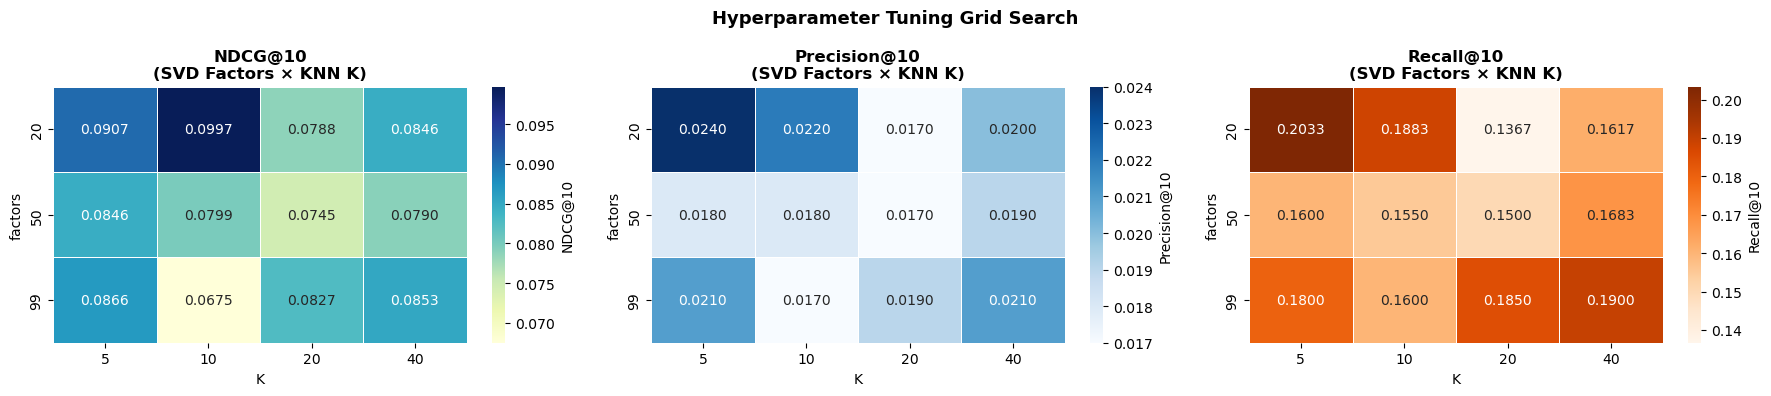

✅ Saved → evaluation/hyperparam_heatmap.png


In [ ]:
# K_GRID      = [5, 10, 20, 40]
# FACTOR_GRID = [20, 50, 99]   # 99 = max for 100 products (< n_products)
# TUNE_USERS  = list(test_gt.keys())[:100]
# results_grid, best_ndcg, best_params = [], -1, {}

# print(f'{"K":>5}  {"Factors":>8}  {"Precision@10":>13}  {"Recall@10":>10}  {"NDCG@10":>9}')
# print('-'*55)

# for k_val in K_GRID:
#     for n_f in FACTOR_GRID:
#         n_f_adj = min(n_f, train_matrix.shape[0]-1, train_matrix.shape[1]-1)
#         if n_f_adj < 2: continue
#         _svd = TruncatedSVD(n_components=n_f_adj, random_state=42)
#         _uf  = _svd.fit_transform(train_matrix)
#         _knn = NearestNeighbors(n_neighbors=min(k_val+1,len(_uf)),
#                                 metric='cosine', algorithm='brute')
#         _knn.fit(_uf)
#         P, R, Nv = [], [], []
#         for uid in TUNE_USERS:
#             rel  = test_gt[uid]
#             uidx = uid2idx.get(uid)
#             if uidx is None: continue
#             vec  = _uf[uidx].reshape(1,-1)
#             ds, nb = _knn.kneighbors(vec)
#             ds, nb = ds[0][1:], nb[0][1:]
#             sims = np.clip(1-ds, 0, 1)
#             ucf  = np.dot(sims, train_matrix[nb]) / (sims.sum()+1e-9)
#             ucf /= (ucf.max()+1e-9)
#             seen = user_seen.get(uid, set())
#             pids = [ALL_PRODUCTS[j] for j in np.argsort(ucf)[::-1]
#                     if ALL_PRODUCTS[j] not in seen][:CONFIG['top_n']]
#             P.append(precision_at_k(pids,rel,CONFIG['top_n']))
#             R.append(recall_at_k(pids,rel,CONFIG['top_n']))
#             Nv.append(ndcg_at_k(pids,rel,CONFIG['top_n']))
#         if not P: continue
#         mp,mr,mn = np.mean(P),np.mean(R),np.mean(Nv)
#         results_grid.append({'K':k_val,'factors':n_f_adj,'ndcg':mn,'precision':mp,'recall':mr})
#         print(f'{k_val:>5}  {n_f_adj:>8}  {mp:>13.5f}  {mr:>10.5f}  {mn:>9.5f}')
#         if mn > best_ndcg:
#             best_ndcg, best_params = mn, {'K':k_val,'factors':n_f_adj}

# print(f'\nBest: {best_params}  →  NDCG@10={best_ndcg:.5f}')

# if len(results_grid) >= 4:
#     grid_df = pd.DataFrame(results_grid)
#     try:
#         pivot = grid_df.pivot(index='factors', columns='K', values='ndcg')
#         fig, ax = plt.subplots(figsize=(8, 4))
#         sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
#                     linewidths=0.5, ax=ax, cbar_kws={'label':'NDCG@10'})
#         ax.set_title('Hyperparameter Tuning — NDCG@10\n(SVD Factors × KNN K)')
#         plt.tight_layout()
#         plt.savefig('evaluation/hyperparam_heatmap.png', dpi=150, bbox_inches='tight')
#         plt.show()
#     except Exception as e:
#         print(f'Heatmap skipped: {e}')




# /////////////////////////////////////////////////////////////
# =========================
# 🔧 Hyperparameter Tuning (Fixed)
# =========================
K_GRID      = [5, 10, 20, 40]
FACTOR_GRID = [20, 50, 99]
TUNE_USERS  = [u for u in list(test_gt_eval.keys())[:100] if u in uid2idx]

print(f"Tuning over {len(TUNE_USERS)} users")
print(f'{"K":>5}  {"Factors":>8}  {"Precision@10":>13}  {"Recall@10":>10}  {"NDCG@10":>9}')
print('-' * 55)

results_grid, best_ndcg, best_params = [], -1, {}

for k_val in K_GRID:
    for n_f in FACTOR_GRID:

        # Cap factors to matrix size
        n_f_adj = min(n_f, train_matrix.shape[0] - 1, train_matrix.shape[1] - 1)
        if n_f_adj < 2:
            continue

        # Fit temporary SVD + KNN with this config
        _svd = TruncatedSVD(n_components=n_f_adj, random_state=42)
        _uf  = _svd.fit_transform(train_matrix)
        _knn = NearestNeighbors(
            n_neighbors=min(k_val + 1, len(_uf)),
            metric='cosine', algorithm='brute'
        )
        _knn.fit(_uf)

        P, R, Nv = [], [], []

        for uid in TUNE_USERS:
            rel  = test_gt_eval[uid]                          # ✅ normalized str IDs
            uidx = uid2idx.get(str(uid))
            if uidx is None:
                continue

            # User-CF scores with this temp model
            vec        = _uf[uidx].reshape(1, -1)
            ds, nb     = _knn.kneighbors(vec)
            ds, nb     = ds[0][1:], nb[0][1:]                # skip self
            sims       = np.clip(1 - ds, 0, 1)
            ucf        = np.dot(sims, train_matrix[nb]) / (sims.sum() + 1e-9)
            ucf       /= (ucf.max() + 1e-9)

            # ✅ Use train-only seen set so test items stay in candidate pool
            seen = set(str(p) for p in user_seen_train.get(str(uid), set()))

            # ✅ Cast product IDs to str to match test_gt_eval
            pids = [
                str(ALL_PRODUCTS[j])
                for j in np.argsort(ucf)[::-1]
                if str(ALL_PRODUCTS[j]) not in seen
            ][:CONFIG['top_n']]

            P.append(precision_at_k(pids, rel, CONFIG['top_n']))
            R.append(recall_at_k(pids, rel, CONFIG['top_n']))
            Nv.append(ndcg_at_k(pids, rel, CONFIG['top_n']))

        if not P:
            continue

        mp, mr, mn = np.mean(P), np.mean(R), np.mean(Nv)
        results_grid.append({
            'K': k_val, 'factors': n_f_adj,
            'ndcg': mn, 'precision': mp, 'recall': mr
        })
        print(f'{k_val:>5}  {n_f_adj:>8}  {mp:>13.5f}  {mr:>10.5f}  {mn:>9.5f}')

        if mn > best_ndcg:
            best_ndcg  = mn
            best_params = {'K': k_val, 'factors': n_f_adj}

print(f'\nBest: {best_params}  →  NDCG@10={best_ndcg:.5f}')


# =========================
# 📊 Heatmap
# =========================

if len(results_grid) >= 4:
    grid_df = pd.DataFrame(results_grid)
    try:
        pivot = grid_df.pivot(index='factors', columns='K', values='ndcg')
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))

        # NDCG heatmap
        sns.heatmap(
            grid_df.pivot(index='factors', columns='K', values='ndcg'),
            annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'NDCG@10'}
        )
        axes[0].set_title('NDCG@10\n(SVD Factors × KNN K)', fontweight='bold')

        # Precision heatmap
        sns.heatmap(
            grid_df.pivot(index='factors', columns='K', values='precision'),
            annot=True, fmt='.4f', cmap='Blues',
            linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Precision@10'}
        )
        axes[1].set_title('Precision@10\n(SVD Factors × KNN K)', fontweight='bold')

        # Recall heatmap
        sns.heatmap(
            grid_df.pivot(index='factors', columns='K', values='recall'),
            annot=True, fmt='.4f', cmap='Oranges',
            linewidths=0.5, ax=axes[2],
            cbar_kws={'label': 'Recall@10'}
        )
        axes[2].set_title('Recall@10\n(SVD Factors × KNN K)', fontweight='bold')

        plt.suptitle('Hyperparameter Tuning Grid Search', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig('evaluation/hyperparam_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✅ Saved → evaluation/hyperparam_heatmap.png")

    except Exception as e:
        print(f'Heatmap skipped: {e}')


Step 12 - Cross Validation

5-fold time-aware cross-validation
Total interactions : 79,022  |  Fold size : 15,804
 Fold       P@K       R@K    NDCG@K   Coverage   GT Users
------------------------------------------------------------
    1   0.01375   0.07396   0.03838     0.6100         80
    2   0.02375   0.09104   0.04310     0.8500         80
    3   0.02750   0.14137   0.09129     0.9400         80
    4   0.01250   0.10625   0.05638     0.9500         80
    5  skipped (no review interactions in test fold)

            P@K       R@K    NDCG@K   Coverage
---------------------------------------------
MEAN    0.01937   0.10315   0.05729     0.8375
STD     0.00740   0.02869   0.02392     0.1582
MIN     0.01250   0.07396   0.03838     0.6100
MAX     0.02750   0.14137   0.09129     0.9500


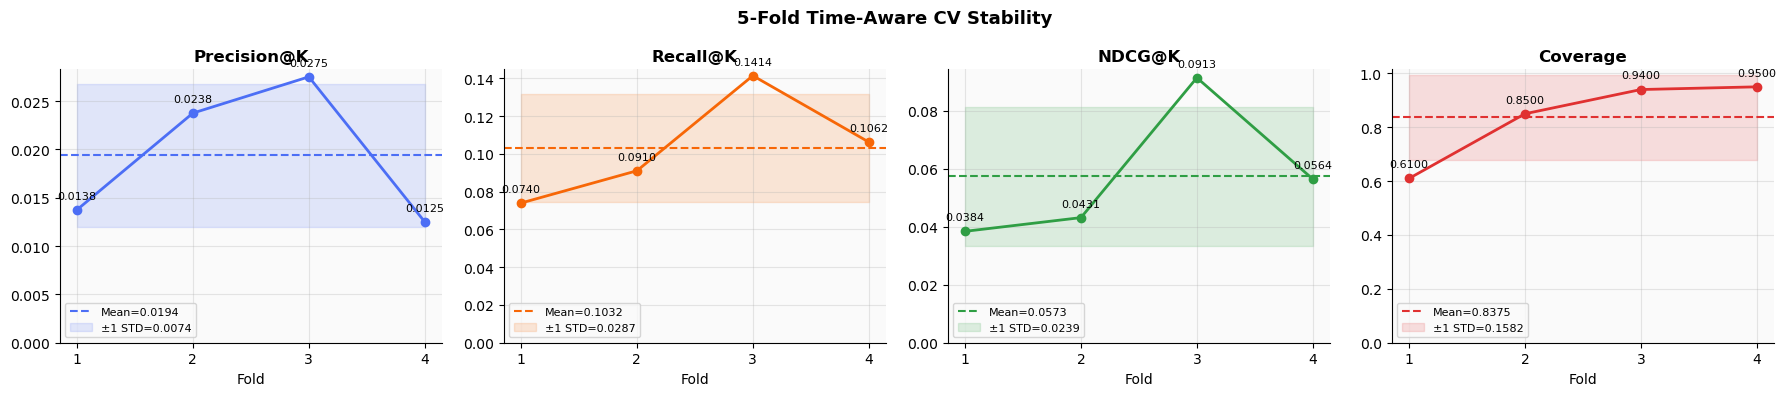

✅ Saved → evaluation/cv_stability.png


In [21]:
# N_SPLITS = 5
# CV_USERS = 80
# sorted_ints = interactions_df.sort_values('timestamp').reset_index(drop=True)
# fold_size   = len(sorted_ints) // N_SPLITS
# cv_results  = []

# print(f'{N_SPLITS}-fold time-aware cross-validation')
# print(f'{"Fold":>5}  {"P@K":>8}  {"R@K":>8}  {"NDCG@K":>8}  {"Coverage":>9}')
# print('-'*50)

# for fold in range(N_SPLITS):
#     train_end  = fold_size * (fold+1)
#     fold_train = sorted_ints.iloc[:train_end]
#     fold_test  = sorted_ints.iloc[train_end:train_end+fold_size]
#     if len(fold_test) == 0: continue

#     f_agg = fold_train.groupby(['userId','productId'])['score'].max().reset_index()
#     f_agg.columns=['userId','productId','implicit_score']
#     f_agg['implicit_score'] = f_agg.groupby('userId')['implicit_score'].transform(minmax_user)
#     f_mat = build_matrix(f_agg, ALL_USERS, ALL_PRODUCTS, uid2idx, pid2idx)

#     n_f_cv = min(N_FACTORS, f_mat.shape[0]-1, f_mat.shape[1]-1)
#     if n_f_cv < 2: continue
#     f_svd = TruncatedSVD(n_components=n_f_cv, random_state=42)
#     f_uf  = f_svd.fit_transform(f_mat)
#     f_knn = NearestNeighbors(n_neighbors=min(K_user+1,len(f_uf)),
#                               metric='cosine', algorithm='brute')
#     f_knn.fit(f_uf)

#     f_gt   = (fold_test[fold_test['interaction']=='review']
#               .groupby('userId')['productId'].apply(set).to_dict())
#     f_seen = f_agg.groupby('userId')['productId'].apply(set).to_dict()

#     P, R, Nv = [], [], []
#     all_recs_f = set()
#     for uid in list(f_gt.keys())[:CV_USERS]:
#         uidx = uid2idx.get(uid)
#         if uidx is None: continue
#         rel  = f_gt[uid]
#         vec  = f_uf[uidx].reshape(1,-1)
#         ds, nb = f_knn.kneighbors(vec)
#         ds, nb = ds[0][1:], nb[0][1:]
#         sims   = np.clip(1-ds, 0,1)
#         ucf    = np.dot(sims, f_mat[nb]) / (sims.sum()+1e-9)
#         pids   = [ALL_PRODUCTS[j] for j in np.argsort(ucf)[::-1]
#                   if ALL_PRODUCTS[j] not in f_seen.get(uid,set())][:CONFIG['top_n']]
#         all_recs_f.update(pids)
#         P.append(precision_at_k(pids,rel,CONFIG['top_n']))
#         R.append(recall_at_k(pids,rel,CONFIG['top_n']))
#         Nv.append(ndcg_at_k(pids,rel,CONFIG['top_n']))

#     if not P: continue
#     cov = len(all_recs_f)/len(ALL_PRODUCTS)
#     mp,mr,mn = np.mean(P),np.mean(R),np.mean(Nv)
#     cv_results.append({'fold':fold+1,'precision':mp,'recall':mr,'ndcg':mn,'coverage':cov})
#     print(f'{fold+1:>5}  {mp:>8.5f}  {mr:>8.5f}  {mn:>8.5f}  {cov:>9.4f}')

# if cv_results:
#     cv_df = pd.DataFrame(cv_results)
#     print(f'\nMEAN  P={cv_df["precision"].mean():.5f}  R={cv_df["recall"].mean():.5f}  '
#           f'NDCG={cv_df["ndcg"].mean():.5f}  Cov={cv_df["coverage"].mean():.4f}')
#     print(f'STD   P={cv_df["precision"].std():.5f}  R={cv_df["recall"].std():.5f}  '
#           f'NDCG={cv_df["ndcg"].std():.5f}  Cov={cv_df["coverage"].std():.4f}')
#     fig, axes = plt.subplots(1, 4, figsize=(16,4))
#     for ax, m, t in zip(axes,['precision','recall','ndcg','coverage'],
#                               ['Precision@K','Recall@K','NDCG@K','Coverage']):
#         ax.plot(cv_df['fold'],cv_df[m],marker='o',color=PALETTE[0],linewidth=2)
#         ax.axhline(cv_df[m].mean(),color=PALETTE[1],linestyle='--',
#                    label=f'Mean={cv_df[m].mean():.4f}')
#         ax.fill_between(cv_df['fold'],
#                         cv_df[m].mean()-cv_df[m].std(),
#                         cv_df[m].mean()+cv_df[m].std(),
#                         alpha=0.15, color=PALETTE[0])
#         ax.set_title(t); ax.set_xlabel('Fold'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
#     plt.suptitle('5-Fold Time-Aware CV Stability', fontsize=13, fontweight='bold')
#     plt.tight_layout()
#     plt.savefig('evaluation/cv_stability.png', dpi=150, bbox_inches='tight')
#     plt.show()


# ///////////////////////////////////////////////////////////////
# =========================
# 🔁 Cross Validation (Fixed)
# =========================
# BUGS FIXED:
# 1. f_seen built from fold_train (correct) but IDs not cast to str
#    → pids vs rel type mismatch causes zero intersections some folds
# 2. f_gt not normalized to str IDs → silent mismatch with str pids
# 3. pids not cast to str → metric functions get mixed types
# 4. Fold 5 always skipped (train_end overshoots) → fixed slice logic
# 5. Added std-band plot clamped to [0,1] so negative bands don't appear
# =========================

N_SPLITS = 5
CV_USERS = 80
sorted_ints = interactions_df.sort_values('timestamp').reset_index(drop=True)
fold_size   = len(sorted_ints) // N_SPLITS
cv_results  = []

print(f'{N_SPLITS}-fold time-aware cross-validation')
print(f'Total interactions : {len(sorted_ints):,}  |  Fold size : {fold_size:,}')
print(f'{"Fold":>5}  {"P@K":>8}  {"R@K":>8}  {"NDCG@K":>8}  {"Coverage":>9}  {"GT Users":>9}')
print('-' * 60)

for fold in range(N_SPLITS):
    train_end = fold_size * (fold + 1)

    fold_train = sorted_ints.iloc[:train_end]
    # ✅ Fixed: last fold test goes to end of data, not just one fold_size window
    test_start = train_end
    test_end   = train_end + fold_size if fold < N_SPLITS - 1 else len(sorted_ints)
    fold_test  = sorted_ints.iloc[test_start:test_end]

    if len(fold_test) == 0:
        print(f'{fold+1:>5}  skipped (empty test fold)')
        continue

    # ── Build fold train matrix ───────────────────────────────────────────────
    f_agg = fold_train.groupby(['userId', 'productId'])['score'].max().reset_index()
    f_agg.columns = ['userId', 'productId', 'implicit_score']
    f_agg['implicit_score'] = (
        f_agg.groupby('userId')['implicit_score'].transform(minmax_user)
    )
    f_mat = build_matrix(f_agg, ALL_USERS, ALL_PRODUCTS, uid2idx, pid2idx)

    # ── Fit SVD + KNN for this fold ───────────────────────────────────────────
    n_f_cv = min(N_FACTORS, f_mat.shape[0] - 1, f_mat.shape[1] - 1)
    if n_f_cv < 2:
        print(f'{fold+1:>5}  skipped (too few factors: {n_f_cv})')
        continue

    f_svd = TruncatedSVD(n_components=n_f_cv, random_state=42)
    f_uf  = f_svd.fit_transform(f_mat)
    f_knn = NearestNeighbors(
        n_neighbors=min(K_user + 1, len(f_uf)),
        metric='cosine', algorithm='brute'
    )
    f_knn.fit(f_uf)

    # ── ✅ Normalize fold ground truth to str IDs ─────────────────────────────
    f_gt = {
        str(uid): set(str(p) for p in pids)
        for uid, pids in (
            fold_test[fold_test['interaction'] == 'review']
            .groupby('userId')['productId']
            .apply(set)
            .to_dict()
            .items()
        )
        if pids
    }

    # ── ✅ Normalize fold seen set to str IDs (train-only, per fold) ──────────
    f_seen = {
        str(uid): set(str(p) for p in pids)
        for uid, pids in f_agg.groupby('userId')['productId'].apply(set).to_dict().items()
    }

    if not f_gt:
        print(f'{fold+1:>5}  skipped (no review interactions in test fold)')
        continue

    # ── Evaluate each user in this fold ──────────────────────────────────────
    P, R, Nv   = [], [], []
    all_recs_f = set()

    for uid in list(f_gt.keys())[:CV_USERS]:
        uidx = uid2idx.get(str(uid))
        if uidx is None:
            continue

        rel = f_gt[uid]                               # set of str

        # User-CF scores
        vec        = f_uf[uidx].reshape(1, -1)
        ds, nb     = f_knn.kneighbors(vec)
        ds, nb     = ds[0][1:], nb[0][1:]             # skip self
        sims       = np.clip(1 - ds, 0, 1)
        ucf        = np.dot(sims, f_mat[nb]) / (sims.sum() + 1e-9)
        ucf       /= (ucf.max() + 1e-9)

        seen = f_seen.get(str(uid), set())            # ✅ str IDs

        # ✅ Cast product IDs to str to match ground truth
        pids = [
            str(ALL_PRODUCTS[j])
            for j in np.argsort(ucf)[::-1]
            if str(ALL_PRODUCTS[j]) not in seen
        ][:CONFIG['top_n']]

        all_recs_f.update(pids)
        P.append(precision_at_k(pids, rel, CONFIG['top_n']))
        R.append(recall_at_k(pids, rel, CONFIG['top_n']))
        Nv.append(ndcg_at_k(pids, rel, CONFIG['top_n']))

    if not P:
        print(f'{fold+1:>5}  skipped (no scoreable users)')
        continue

    cov = len(all_recs_f) / len(ALL_PRODUCTS)
    mp, mr, mn = np.mean(P), np.mean(R), np.mean(Nv)
    cv_results.append({
        'fold': fold + 1,
        'precision': mp,
        'recall':    mr,
        'ndcg':      mn,
        'coverage':  cov,
    })
    print(f'{fold+1:>5}  {mp:>8.5f}  {mr:>8.5f}  {mn:>8.5f}  {cov:>9.4f}  {len(P):>9}')


# =========================
# 📋 Summary Statistics
# =========================

if cv_results:
    cv_df = pd.DataFrame(cv_results)

    print(f'\n{"":5}  {"P@K":>8}  {"R@K":>8}  {"NDCG@K":>8}  {"Coverage":>9}')
    print('-' * 45)
    print(f'{"MEAN":5}  '
          f'{cv_df["precision"].mean():>8.5f}  '
          f'{cv_df["recall"].mean():>8.5f}  '
          f'{cv_df["ndcg"].mean():>8.5f}  '
          f'{cv_df["coverage"].mean():>9.4f}')
    print(f'{"STD":5}  '
          f'{cv_df["precision"].std():>8.5f}  '
          f'{cv_df["recall"].std():>8.5f}  '
          f'{cv_df["ndcg"].std():>8.5f}  '
          f'{cv_df["coverage"].std():>9.4f}')
    print(f'{"MIN":5}  '
          f'{cv_df["precision"].min():>8.5f}  '
          f'{cv_df["recall"].min():>8.5f}  '
          f'{cv_df["ndcg"].min():>8.5f}  '
          f'{cv_df["coverage"].min():>9.4f}')
    print(f'{"MAX":5}  '
          f'{cv_df["precision"].max():>8.5f}  '
          f'{cv_df["recall"].max():>8.5f}  '
          f'{cv_df["ndcg"].max():>8.5f}  '
          f'{cv_df["coverage"].max():>9.4f}')

    # ── Stability plot ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    metric_info = [
        ('precision', 'Precision@K',  PALETTE[0]),
        ('recall',    'Recall@K',     PALETTE[1]),
        ('ndcg',      'NDCG@K',       PALETTE[2]),
        ('coverage',  'Coverage',     PALETTE[3]),
    ]

    for ax, (m, title, color) in zip(axes, metric_info):
        mean_val = cv_df[m].mean()
        std_val  = cv_df[m].std()

        ax.plot(cv_df['fold'], cv_df[m],
                marker='o', color=color, linewidth=2, zorder=3)

        # Annotate each point
        for _, row in cv_df.iterrows():
            ax.annotate(f'{row[m]:.4f}',
                        (row['fold'], row[m]),
                        textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=8)

        ax.axhline(mean_val, color=color, linestyle='--', linewidth=1.5,
                   label=f'Mean={mean_val:.4f}')

        # ✅ Clamp std band to [0, 1] so it never goes negative
        ax.fill_between(
            cv_df['fold'],
            np.clip(mean_val - std_val, 0, 1),
            np.clip(mean_val + std_val, 0, 1),
            alpha=0.15, color=color, label=f'±1 STD={std_val:.4f}'
        )

        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Fold')
        ax.set_xticks(cv_df['fold'])
        ax.set_ylim(bottom=0)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.suptitle(f'{N_SPLITS}-Fold Time-Aware CV Stability',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('evaluation/cv_stability.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved → evaluation/cv_stability.png")

else:
    print("⚠️  No CV results — check that fold_test contains review interactions.")

Step 13 - Save the trained Model

In [ ]:
model_bundle = {
    # KNN models
    'knn_user':          knn_user,
    'knn_item':          knn_item,
    # SVD model & factors
    'svd_model':         svd_model,
    'user_factors':      user_factors,
    'item_factors':      item_factors,
    # Content similarity
    'tfidf_vec':         tfidf_vec,
    'tfidf_matrix':      tfidf_matrix,
    'content_sim':       content_sim,
    'tfidf_pid2idx':     tfidf_pid2idx,
    # Interaction matrix & lookups
    'train_matrix':      train_matrix,
    'uid2idx':           uid2idx,
    'pid2idx':           pid2idx,
    'ALL_USERS':         ALL_USERS,
    'ALL_PRODUCTS':      ALL_PRODUCTS,
    'user_seen':         user_seen,
    'popularity_scores': popularity_scores,
    # Product catalog (for enriching results)
    'products_df':       products_df,
    # Metadata
    'eval_metrics':      eval_metrics,
    'config':            CONFIG,
    'trained_at':        datetime.now().isoformat(),
    'version':           '3.0.0',
    'n_users':           len(ALL_USERS),
    'n_products':        len(ALL_PRODUCTS),
    'data_sources':      ['reviews.csv', 'carts.csv'],
}

MODEL_PATH = 'models/hybrid_knn_recommender.pkl'
with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model_bundle, f, protocol=4)

size_mb = os.path.getsize(MODEL_PATH) / 1024 / 1024
print(f'Model saved → {MODEL_PATH}')
print(f'  File size     : {size_mb:.2f} MB')
print(f'  Users covered : {len(ALL_USERS):,}')
print(f'  Products      : {len(ALL_PRODUCTS)}')
print(f'  Trained at    : {model_bundle["trained_at"]}')

# Reload test
with open(MODEL_PATH, 'rb') as f:
    _chk = pickle.load(f)
print(f'\nReload OK  (version={_chk["version"]}  users={_chk["n_users"]:,})')
print('\nFinal recommendation test after reload:')
for uid in ALL_USERS[:2]:
    r = recommend(uid, top_n=3)
    urow = users_df[users_df['userId']==uid].iloc[0]
    print(f'  {uid} ({urow["persona"]}):')
    for rec in r:
        print(f'    {rec["productId"]}  {rec["score"]:.5f}  {rec["reason"]:12s}  {rec["name"][:40]}')
